# Análise do trace cru — esteira de agentes do fluxo jurídico

**Notebook genérico:** roda sobre qualquer extração apontada por `TRACE` em `base_pipeline.py`. Cada célula
calcula e mostra; a **leitura dos resultados de cada run** fica nos docs daquele run (para a base 1:
[`../docs/02-relatorio-achados.md`](../docs/02-relatorio-achados.md) e [`../docs/01-racionais.md`](../docs/01-racionais.md)).
Antes de rodar numa base nova: `python checklist.py` (intake — colunas, período real × lotes, `error.type`).

## Por que esta análise

A hipótese do projeto é que o log cru de execução **é a working memory** do sistema. Se conseguirmos extrair e
categorizar sinais de erro desse log, esses sinais são os primeiros candidatos a **unidades de memória** e, adiante,
a **memórias experienciais/procedurais**.

## Como a taxonomia classifica

Por **causa-raiz**, não por sintoma: a mensagem de erro é lida e agrupada pelo que o agente fez de errado (§2), e
não pelo tipo de exceção. A história de como a classificação chegou a esse desenho está em
[`../docs/01-racionais.md`](../docs/01-racionais.md) §1.

## Lentes teóricas (texto completo lido, ver `../literature/`)

| Taxonomia | O que aporta | Ref. |
|---|---|---|
| **MAST** | 14 modos em 3 categorias; **não tem modo para "o código levantou exceção"** — declaradamente fora de escopo | arXiv:2503.13657, NeurIPS 2025 |
| **TRAIL** | Taxonomia para traces (20+ tipos, 841 erros anotados); mapeamento nosso sobre essas categorias estima **≥59% estruturalmente invisíveis a exceção** | arXiv:2505.08638 |
| **AgentDebug** | 17 tipos em 5 módulos; o **módulo roteia o tipo de memória**; política "uma unidade por cascata, na raiz" | arXiv:2509.25370 |
| **ToolScan** (orig. SpecTool) | 7 erros de tool-use; seu **mecanismo de feedback é memória não-paramétrica** | arXiv:2411.13547, ICLR 2025 Workshop |

> **Caveats:** (1) se a extração tiver `LIMIT`, as contagens são amostrais; (2) o `mes` é o mês em que a execução
> rodou (`dat_hor_inio_exeo`), não o lote de corte (`anomesdia`) — `../docs/05-schema.md` §Datas; (3) os nomes dos
> códigos de status vêm do dicionário de status (`05-schema.md` §Status); (4) o payload contém nomes e números
> de processo — não versionar em claro.

In [1]:
%matplotlib inline
import json, re, ast, builtins, unicodedata
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from base_pipeline import *   # espinha compartilhada desta pasta — ver base_pipeline.py

from paleta import *          # cores fixas por NOME (unidade/família) — ver paleta.py
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
})
def style_ax(ax, xgrid=True):
    for s in ("top","right","left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASE)
    g = ax.xaxis if xgrid else ax.yaxis
    g.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)

df = carregar_trace()
print(f"{len(df)} execuções · {df.shape[1]} colunas")


1000 execuções · 14 colunas


## 1 · Explosão da working memory em steps

Cada execução vira N linhas — uma por `ActionStep` de cada papel — com tokens, duração, erro estruturado,
o *thought* (`model_output`), o código gerado (`code_action`) e o contexto recebido (`model_input_messages`).

In [2]:
steps, RAW, execs = explodir_memoria(df)

print(f"{len(steps):,} ActionSteps em {len(execs):,} execuções")
print(f"steps com erro: {steps['err_type'].notna().sum():,} ({steps['err_type'].notna().mean():.1%})")
print(f"execuções com ≥1 erro: {execs['com_erro'].sum():,} ({execs['com_erro'].mean():.1%})")
print(f"tokens totais: {steps['tok_tot'].sum():,.0f}")


5,781 ActionSteps em 840 execuções
steps com erro: 498 (8.6%)
execuções com ≥1 erro: 313 (37.3%)
tokens totais: 142,613,752


## 2 · Taxonomia por causa-raiz

O tipo nativo (`AgentExecutionError`, `AgentParsingError`) é um balde genérico. A classificação abaixo lê a
**mensagem** e agrupa por causa, não por sintoma — a correção central da v2.

In [3]:
E = classificar_erros(steps)

print("Erros por família:")
display(E["familia"].value_counts().to_frame("erros").assign(
    pct=lambda d: (d["erros"]/d["erros"].sum()*100).round(1)))
print("Erros por assinatura:")
display(E.groupby(["familia","assinatura"]).size().sort_values(ascending=False).to_frame("erros"))
print(f"sintoma não reconhecido: {(E['familia']=='Sintoma não reconhecido').sum()} de {len(E)}")
print("\nPapéis mais afetados:")
display(E["role"].value_counts().head(8).to_frame("erros").T)


Erros por família:


,erros,pct
familia,,
Geração de código,225,45.2
Contrato de retorno da ferramenta,168,33.7
Convenção de chamada de ferramenta,35,7.0
Protocolo do harness,33,6.6
Ambiente & sandbox,19,3.8
Suposição sobre estado,8,1.6
Infra / LLM upstream,7,1.4
Suposição sobre dados,2,0.4
Sintoma não reconhecido,1,0.2


Erros por assinatura:


,,erros
familia,assinatura,
Geração de código,String não fechada (relatório longo em literal),159
Contrato de retorno da ferramenta,Falha ao indexar o retorno (Could not index),136
Geração de código,Sintaxe inválida,39
Convenção de chamada de ferramenta,Argumento posicional onde só cabe nomeado,35
Protocolo do harness,Resposta sem bloco de código (harness),33
Contrato de retorno da ferramenta,Tipo diferente do esperado,22
Geração de código,Texto do documento colado em literal,20
Ambiente & sandbox,Função ou import bloqueado pelo sandbox,11
Suposição sobre estado,Variável não definida,8


sintoma não reconhecido: 1 de 498

Papéis mais afetados:


role,ConversationAgent,managerAgent,RespostaBacen,CadastroTrabalhista,CalculoCivel,RoteadorCivel,CalculoTrabalhista,CadastroCivel
erros,224,180,24,18,17,14,7,5


### Do sintoma ao mecanismo

A `assinatura` acima é o **sintoma**: a mensagem que o Python devolveu. Mensagens iguais podem vir de erros diferentes — "Could not index" aparece tanto quando o agente indexa um dict por posição quanto quando trata um texto como dict. A célula abaixo atribui a cada erro o **mecanismo** (o que o agente fez de errado), por regra fixa sobre a mensagem e a linha rejeitada pelo parser, sem LLM, e agrupa os mecanismos em **unidades** (uma lição, numa frase).

Onde a pergunta é de inventário ou custo, o notebook continua usando a assinatura (§2, §2.3, §3.2, §8.1). Onde a pergunta é "qual erro se repete / qual lição escrever", usa o mecanismo: §2.2, o payoff da §3, §5, §6, §8.4, §8.5, §8.8 e §9. Regras e critérios em [`../docs/01-racionais.md`](../docs/01-racionais.md) §7.

In [4]:
EU = montar_unidades(E)

display(EU["submecanismo"].value_counts().to_frame("erros"))


,erros
submecanismo,
texto_em_literal,186
dict_indexado_por_posicao,89
tipo_real_do_retorno,47
argumento_posicional,35
harness_bloco_code,33
texto_solto_no_codigo,33
next_sobre_gerador,13
inventario_sandbox,11
campo_inexistente_no_retorno,10


### 2.1 · Teste direto da afirmação sobre o ToolScan

Hipótese testada: a família "suposição sobre dados" seria o equivalente CodeAgent dos **erros de argumento** do
ToolScan (IAN = nome de argumento alucinado, IAV = argumento obrigatório omitido). O teste abaixo quebra o balde
`TypeError` pelos padrões de mensagem que identificam IAN e IAV. **Como ler:** se IAN + IAV forem a minoria do balde, a
hipótese não se sustenta para esta base.

In [5]:
te = Counter()
for m in E.loc[E["err_msg"].str.contains("TypeError"), "err_msg"]:
    if 'unexpected keyword argument' in m:            te['IAN — argumento nomeado inexistente'] += 1
    elif 'required positional argument' in m:         te['IAV — argumento obrigatório omitido'] += 1
    elif 'not subscriptable' in m or 'not iterable' in m: te['Contrato de retorno (não indexável)'] += 1
    else:                                             te['Outro TypeError'] += 1
display(pd.Series(te).sort_values(ascending=False).to_frame("ocorrências"))
print(f"IAN + IAV: {te['IAN — argumento nomeado inexistente'] + te['IAV — argumento obrigatório omitido']} "
      f"de {sum(te.values())} TypeError")

,ocorrências
Outro TypeError,59
IAN — argumento nomeado inexistente,1


IAN + IAV: 1 de 60 TypeError


### 2.2 · Mecanismo de erro por papel

**Racional:** a família dominante do dataset inteiro mistura todos os papéis numa média. Se cada papel de domínio erra por uma causa **diferente e concentrada**, a média geral esconde exatamente o padrão mais acionável: qual unidade de memória resolve qual papel. Normalizar por linha (% dos erros DAQUELE papel, não do total) é o que revela isso.

**Por mecanismo, não por mensagem** (célula "Do sintoma ao mecanismo", acima): a pergunta aqui é "qual lição escrever para este papel", e a mensagem engana. O corte `role_vol >= 5` só decide quais papéis aparecem; o % dentro de cada papel não depende dele.

In [6]:
role_vol = EU["role"].value_counts()
roles_relevantes = role_vol[role_vol >= 5].index
nome_mec = EU["unidade"].map(lambda u: UNI[u][0])
tab_role_mec = pd.crosstab(EU["role"], nome_mec).loc[roles_relevantes]
norm_mec = tab_role_mec.div(tab_role_mec.sum(axis=1), axis=0) * 100
dom22 = pd.DataFrame({
    "n": tab_role_mec.sum(axis=1),
    "mecanismo dominante": norm_mec.idxmax(axis=1),
    "% do papel": norm_mec.max(axis=1).round().astype(int),
    "2º mecanismo": norm_mec.apply(lambda r: r.nlargest(2).index[1], axis=1),
    "% 2º": norm_mec.apply(lambda r: r.nlargest(2).iloc[1], axis=1).round().astype(int),
})
print("Mecanismo dominante por papel (% dos erros DAQUELE papel):")
display(dom22)
for role, r in dom22.iterrows():
    empate = f" — empate com '{r['2º mecanismo']}'" if r["% do papel"] == r["% 2º"] else ""
    print(f"{role}: {r['% do papel']}% '{r['mecanismo dominante']}'{empate}")

Mecanismo dominante por papel (% dos erros DAQUELE papel):


,n,mecanismo dominante,% do papel,2º mecanismo,% 2º
role,,,,,
ConversationAgent,224,Retorno das ferramentas de documento é dict,43,Texto longo nunca dentro de literal de string,29
managerAgent,180,Texto longo nunca dentro de literal de string,62,Explicação nunca solta no bloco de código,15
RespostaBacen,24,Campo inexistente no retorno estruturado,33,Retorno pode chegar como string,33
CadastroTrabalhista,18,Ferramentas só aceitam argumento nomeado,94,Texto longo nunca dentro de literal de string,6
CalculoCivel,17,Retorno pode chegar como string,76,Protocolo do harness,12
RoteadorCivel,14,Ferramentas só aceitam argumento nomeado,43,Retorno pode chegar como string,29
CalculoTrabalhista,7,Ferramentas só aceitam argumento nomeado,43,Retorno pode chegar como string,43
CadastroCivel,5,Texto longo nunca dentro de literal de string,100,"Após step com erro, o que ele definiria não ex...",0


ConversationAgent: 43% 'Retorno das ferramentas de documento é dict'
managerAgent: 62% 'Texto longo nunca dentro de literal de string'
RespostaBacen: 33% 'Campo inexistente no retorno estruturado' — empate com 'Retorno pode chegar como string'
CadastroTrabalhista: 94% 'Ferramentas só aceitam argumento nomeado'
CalculoCivel: 76% 'Retorno pode chegar como string'
RoteadorCivel: 43% 'Ferramentas só aceitam argumento nomeado'
CalculoTrabalhista: 43% 'Ferramentas só aceitam argumento nomeado' — empate com 'Retorno pode chegar como string'
CadastroCivel: 100% 'Texto longo nunca dentro de literal de string'


### 2.3 · Duração por assinatura de erro

**Racional:** todo o custo medido até aqui foi em tokens. Duração (segundos de wall-clock por step) é um eixo
independente — um erro pode ser barato em tokens e ainda assim caro em tempo de espera (ex.: uma chamada que
trava aguardando timeout de infraestrutura). Vale checar se as duas medidas de custo concordam.

**Como ler:** a primeira tabela inclui assinaturas com poucos casos (n≥3); a segunda só as com amostra confiável
(n≥20). Tire conclusões da segunda: medianas com poucos pontos variam em ordens de grandeza e não sobrevivem a um
corte de amostra razoável (teste de robustez em [`../docs/03-procedimento-validacao.md`](../docs/03-procedimento-validacao.md) §1.6).

In [7]:
dur_fam = E.groupby("assinatura")["dur_s"].agg(["median", "size"]).sort_values("median", ascending=False)

print("assinaturas com n >= 3:")
display(dur_fam[dur_fam["size"] >= 3].round(1))

print("\nassinaturas com n >= 20:")
confiavel = dur_fam[dur_fam["size"] >= 20]
display(confiavel.round(1))


assinaturas com n >= 3:


,median,size
assinatura,,
Falha do LLM interno,115.2,6
Módulo usado sem import,65.0,6
Texto do documento colado em literal,15.6,20
Resposta sem bloco de código (harness),15.6,33
Função ou import bloqueado pelo sandbox,15.4,11
Objeto sem o atributo esperado,15.4,8
String não fechada (relatório longo em literal),15.3,159
Variável não definida,11.5,8
Falha ao indexar o retorno (Could not index),7.7,136



assinaturas com n >= 20:


,median,size
assinatura,,
Texto do documento colado em literal,15.6,20
Resposta sem bloco de código (harness),15.6,33
String não fechada (relatório longo em literal),15.3,159
Falha ao indexar o retorno (Could not index),7.7,136
Sintaxe inválida,7.6,39
Tipo diferente do esperado,7.5,22
Argumento posicional onde só cabe nomeado,3.2,35


## 3 · Custo dos erros

In [8]:
tok_total, tok_erro = steps["tok_tot"].sum(), E["tok_tot"].sum()
print(f"tokens em steps com erro: {tok_erro:,.0f} ({tok_erro/tok_total:.1%} do total)")
print("\nCusto por execução — com erro vs sem erro:")
display(execs.groupby("com_erro")[["n_steps","tok_tot","dur_s"]].agg(["median","mean"]).round(0))

payoff = (E.groupby("assinatura").agg(erros=("assinatura","size"), execucoes=("exec_id","nunique"),
          tokens=("tok_tot","sum"), minutos=("dur_s", lambda s: round(s.sum()/60,1)))
          .sort_values("tokens", ascending=False))
payoff["%_tokens_erro"] = (payoff["tokens"]/payoff["tokens"].sum()*100).round(1)
print("\nCusto por mensagem de erro (sintoma):")
display(payoff)

payoff_mec = (EU.assign(mecanismo=EU["unidade"].map(lambda u: UNI[u][0]))
              .groupby("mecanismo").agg(erros=("unidade","size"), execucoes=("exec_id","nunique"),
              tokens=("tok_tot","sum"), minutos=("dur_s", lambda s: round(s.sum()/60,1)))
              .sort_values("tokens", ascending=False))
payoff_mec["%_tokens_erro"] = (payoff_mec["tokens"]/payoff_mec["tokens"].sum()*100).round(1)
print("\nCusto por mecanismo (unidade de memória):")
display(payoff_mec)

tokens em steps com erro: 13,946,017 (9.8% do total)

Custo por execução — com erro vs sem erro:


n_steps        tok_tot            dur_s       
          median mean    median      mean median   mean
com_erro                                               
False        5.0  6.0   47884.0  113240.0  149.0  360.0
True         7.0  9.0  146306.0  264972.0  223.0  346.0


Custo por mensagem de erro (sintoma):


,erros,execucoes,tokens,minutos,%_tokens_erro
assinatura,,,,,
Falha ao indexar o retorno (Could not index),136,119,4687425,41.1,33.6
String não fechada (relatório longo em literal),159,125,3572698,39.0,25.6
Sintaxe inválida,39,18,1491951,8.2,10.7
Função ou import bloqueado pelo sandbox,11,11,907471,4.1,6.5
Resposta sem bloco de código (harness),33,24,811648,12.2,5.8
Tipo diferente do esperado,22,19,520290,5.9,3.7
Objeto sem o atributo esperado,8,8,416625,2.0,3.0
Texto do documento colado em literal,20,20,366287,9.3,2.6
Argumento posicional onde só cabe nomeado,35,22,364543,2.8,2.6



Custo por mecanismo (unidade de memória):


,erros,execucoes,tokens,minutos,%_tokens_erro
mecanismo,,,,,
Texto longo nunca dentro de literal de string,186,149,4038107,50.2,29.0
Retorno das ferramentas de documento é dict,96,87,2989426,18.6,21.4
Retorno pode chegar como string,47,36,2106255,18.2,15.1
Explicação nunca solta no bloco de código,33,12,1388050,6.1,10.0
Inventário do sandbox,17,17,887853,11.4,6.4
Protocolo do harness,33,24,811648,12.2,5.8
Ferramentas só aceitam argumento nomeado,35,22,364543,2.8,2.6
next() sobre expressão geradora falha no sandbox,13,11,339280,3.0,2.4
Nome usado sem ter sido definido,5,5,294106,1.2,2.1


### 3.1 · Sucesso verificado por conteúdo

A recuperação medida na §4 é mecânica — só confirma que `final_answer(...)` foi chamado, não que a resposta
tinha conteúdo. Teste mais exigente: entre as execuções cuja resposta **de fato responde** (não é recusa),
quantas ainda assim tiveram erro pelo caminho?

O status do banco não é usado para separar isso (`05-schema.md` §Status: ele não serve como rótulo de
sucesso/fracasso). Em vez de uma lista de palavras minha, usei
a **fonte autoritativa dentro do próprio system prompt**: ele instrui o agente a responder literalmente
*"Não encontrado na base"* ou *"Informação insuficiente na base"* quando não consegue responder — são as duas
frases exatas usadas aqui, não uma heurística inventada.

**Limite do detector:** só pega essas 2 frases — não pega pedido de esclarecimento, e não avalia se a resposta
é factualmente correta (groundedness, em aberto).

**Como ler:** compare a proporção de execuções com erro dentro do grupo "resposta de conteúdo" com a do dataset
inteiro (§1). Se forem parecidas, o erro não empurra a execução para fora do grupo com resposta boa.

In [9]:
S = medir_sucesso(df)
print(f"execuções com final_answer identificado: {len(S)}")
print("\nresposta com CONTEÚDO (não é recusa) × teve erro na trajetória:")
display(pd.crosstab(S["sucesso"], S["com_erro"]))

suc = S[S["sucesso"]]
print(f"\ndentro das {len(suc)} ({len(suc)/len(S):.1%}) com resposta de conteúdo:")
print(f"  com erro na trajetória: {suc['com_erro'].sum()} ({suc['com_erro'].mean():.1%})")
print(f"  sem erro:               {(~suc['com_erro']).sum()} ({(~suc['com_erro']).mean():.1%})")

print("\ncusto (tokens, mediana) no grupo com resposta de conteúdo:")
display(suc.groupby("com_erro")["tok_tot"].median().round(0).to_frame("tok_tot_mediano"))

fams = Counter()
for lst in suc.loc[suc["com_erro"], "assinaturas"]: fams.update(lst)
print("\nassinaturas de erro nas execuções com resposta de conteúdo (top 8):")
display(pd.Series(fams).sort_values(ascending=False).head(8).to_frame("erros"))
print(f"\nproporção com erro — dataset inteiro: {S['com_erro'].mean():.1%} · grupo com resposta de conteúdo: {suc['com_erro'].mean():.1%}")


execuções com final_answer identificado: 840

resposta com CONTEÚDO (não é recusa) × teve erro na trajetória:


com_erro,False,True
sucesso,,
False,3,3
True,524,310



dentro das 834 (99.3%) com resposta de conteúdo:
  com erro na trajetória: 310 (37.2%)
  sem erro:               524 (62.8%)

custo (tokens, mediana) no grupo com resposta de conteúdo:


,tok_tot_mediano
com_erro,
False,48175.0
True,148402.0



assinaturas de erro nas execuções com resposta de conteúdo (top 8):


,erros
String não fechada (relatório longo em literal),159
Falha ao indexar o retorno (Could not index),136
Sintaxe inválida,38
Argumento posicional onde só cabe nomeado,35
Resposta sem bloco de código (harness),32
Tipo diferente do esperado,22
Texto do documento colado em literal,20
Função ou import bloqueado pelo sandbox,11



proporção com erro — dataset inteiro: 37.3% · grupo com resposta de conteúdo: 37.2%


### 3.2 · Razão input/output por step

**Racional:** hipótese — "string não fechada" acontece quando o agente está *gerando* muito texto (o relatório
jurídico) e "retorno é dict" logo depois de *receber* um payload grande. Essa razão testa isso numericamente: um step que gera muito texto tem razão baixa (pouco input, muito output);
um step que trava ao processar uma entrada grande tem razão alta (muito input, pouco output antes de quebrar).

In [10]:
ok_steps = steps[steps["err_type"].isna() & (steps["tok_out"] > 0)]
print(f"steps OK (geral): mediana in/out = {(ok_steps['tok_in']/ok_steps['tok_out']).median():.1f}")

Er = E[E["tok_out"] > 0].copy()
Er["ratio"] = Er["tok_in"] / Er["tok_out"]
print(f"steps c/ erro (geral): mediana in/out = {Er['ratio'].median():.1f}")
print("\npor assinatura (as 6 maiores medianas):")
display(Er.groupby("assinatura")["ratio"].agg(["median", "size"]).sort_values("median", ascending=False).head(6))

steps OK (geral): mediana in/out = 33.5
steps c/ erro (geral): mediana in/out = 27.6

por assinatura (as 6 maiores medianas):


,median,size
assinatura,,
HTTP 422,308.866873,1
Formato/valor inválido,132.930740,2
Função ou import bloqueado pelo sandbox,90.166240,11
Variável não definida,75.761167,8
Indentação inválida,66.945774,2
Falha ao indexar o retorno (Could not index),58.886501,136


### 3.3 · Tokens por chamada de ferramenta declarada

**Racional:** taxa de erro por papel (§3.1... ver tabela "quem erra" acima) mede *comportamento errado*. Esta
métrica mede algo diferente: quantos tokens o sistema gasta pra produzir **uma unidade de trabalho real**
(uma chamada de ferramenta). Um papel pode ter poucos erros e ainda assim ser caro por chamada — são eixos
independentes, e só aparecem separados quando medidos separadamente.

**Regra de contagem (fixada em 15/09/2026).** Um step cujo `code_action` não parseia — `ast.parse()` levanta
exceção, então não existe árvore pra percorrer e contar chamadas — entra no numerador com **os tokens dele** e
contribui **zero** ao denominador. Esses steps são, por construção, steps que falharam: descartá-los, como a
regra anterior fazia, tiraria da métrica de custo justamente as falhas. Racional completo, as duas contas comparadas e o efeito por papel em
[`../docs/01-racionais.md`](../docs/01-racionais.md) §3.3, Ressalva 2.

In [11]:
import ast
INV_decl = set()
for r in RAW:
    for nome in re.findall(r"def\s+(\w+)\s*\(", r["sysprompt"] or ""):
        INV_decl.add(nome)

por_role_ef = defaultdict(lambda: {"tok": 0, "calls": 0})
# REGRA OFICIAL (15/09/2026): o step entra SEMPRE no numerador, parseie ou não. Se o código tem
# erro de sintaxe — a família de erro mais comum deste trace —, não dá pra contar chamadas nele
# (conta 0), mas os tokens que ele gastou continuam sendo custo real do papel. A regra anterior
# descartava o step inteiro, o que sumia com o custo das falhas mais caras e era inconsistente
# com o próprio por_exec_ef abaixo, que sempre contou os tokens. Ver 01-racionais.md §3.3.
for r in RAW:
    try:
        n_calls = sum(1 for n in ast.walk(ast.parse(r["code"]))
                      if isinstance(n, ast.Call) and isinstance(n.func, ast.Name) and n.func.id in INV_decl)
    except Exception:
        n_calls = 0
    por_role_ef[r["role"]]["tok"] += r["tok_tot"]
    por_role_ef[r["role"]]["calls"] += n_calls

rows_ef = [(role, d["tok"], d["calls"], d["tok"]/d["calls"])
           for role, d in por_role_ef.items() if d["calls"] > 0]
EF = pd.DataFrame(rows_ef, columns=["role", "tok_total", "chamadas", "tok_por_chamada"])
EF = EF.sort_values("tok_por_chamada", ascending=False)
print(f"ferramentas declaradas usadas como referência: {len(INV_decl)}\n")
display(EF)

# duas estatísticas diferentes, de propósito: a razão AGREGADA (soma/soma, dominada pelos
# papéis/execuções de maior volume) e a mediana das razões POR EXECUÇÃO (o caso típico).
# Divergem porque o custo é concentrado (ver §3.4) — não é erro, é o mesmo fenômeno visto 2x.
razao_agregada = EF["tok_total"].sum() / EF["chamadas"].sum()
por_exec_ef = defaultdict(lambda: {"tok": 0, "calls": 0})
for r in RAW:
    try:
        n_calls = sum(1 for n in ast.walk(ast.parse(r["code"]))
                      if isinstance(n, ast.Call) and isinstance(n.func, ast.Name) and n.func.id in INV_decl)
    except Exception:
        n_calls = 0
    por_exec_ef[r["exec_id"]]["tok"] += r["tok_tot"]
    por_exec_ef[r["exec_id"]]["calls"] += n_calls
ratios_exec = [d["tok"]/d["calls"] for d in por_exec_ef.values() if d["calls"] > 0]
mediana_por_exec = pd.Series(ratios_exec).median()
print(f"\nrazão AGREGADA (soma tokens / soma chamadas, todo o dataset): {razao_agregada:,.0f}")
print(f"MEDIANA das razões por execução (a execução típica): {mediana_por_exec:,.0f}")
# agregada > mediana quando o custo é concentrado numa cauda de execuções caras (§3.4)

ferramentas declaradas usadas como referência: 90



<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


,role,tok_total,chamadas,tok_por_chamada
5,CalculoCivel,7933712,56,141673.428571
10,CalculoTrabalhista,3442452,68,50624.294118
13,null,849854,21,40469.238095
1,ConversationAgent,76771559,2743,27988.173168
0,managerAgent,45849326,2442,18775.317772
4,OficiosResposta,297004,16,18562.750000
14,AgenteEstruturador,35339,2,17669.500000
7,RespostaOficios,98205,6,16367.500000
11,OBFCivel,1667672,116,14376.482759
9,RespostaBacen,1833010,229,8004.410480



razão AGREGADA (soma tokens / soma chamadas, todo o dataset): 22,280
MEDIANA das razões por execução (a execução típica): 12,192


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


### 3.4 · Concentração de custo

**Racional:** a execução mais cara é exceção rara, ou o custo total do sistema é dominado por uma cauda pequena de
execuções caras? Importa pra priorização — se o custo está concentrado, otimizar o caso médio rende pouco; o
retorno está em mirar a cauda.

In [12]:
toks_desc = execs["tok_tot"].sort_values(ascending=False).values
total_tok = toks_desc.sum()
n_exec = len(toks_desc)
print("fatia do topo (por tokens) -> % de todo o gasto do sistema:")
for pct in (1, 5, 10, 20, 50):
    k = max(1, round(n_exec * pct / 100))
    share = toks_desc[:k].sum() / total_tok
    print(f"  top {pct:2d}% ({k:3d} de {n_exec} execuções)  ->  {share:.1%} de todos os tokens")


fatia do topo (por tokens) -> % de todo o gasto do sistema:
  top  1% (  8 de 840 execuções)  ->  16.8% de todos os tokens
  top  5% ( 42 de 840 execuções)  ->  41.9% de todos os tokens
  top 10% ( 84 de 840 execuções)  ->  54.6% de todos os tokens
  top 20% (168 de 840 execuções)  ->  69.1% de todos os tokens
  top 50% (420 de 840 execuções)  ->  89.8% de todos os tokens


### 3.5 · Desperdício como % do orçamento de cada papel

**Racional:** taxa de erro (§3.1 acima) e tokens/chamada (§3.3) não perguntam "quantos tokens absolutos foram
desperdiçados". Um papel com taxa de erro moderada mas volume gigantesco pode desperdiçar, em números
absolutos, mais que todos os outros somados — e isso muda a resposta de "qual é a prioridade" dependendo do
critério usado.

In [13]:
def orcamento(g):
    return pd.Series({"tok_total": g["tok_tot"].sum(),
                       "tok_erro": g.loc[g["err_type"].notna(), "tok_tot"].sum()})

OR = steps.groupby("role").apply(orcamento, include_groups=False)
OR = OR[OR["tok_total"] >= 50_000].copy()
OR["%_desperdicado"] = (OR["tok_erro"] / OR["tok_total"] * 100).round(1)
print("por % do orçamento desperdiçado:")
display(OR.sort_values("%_desperdicado", ascending=False))
print("\npor volume absoluto desperdiçado:")
display(OR.sort_values("tok_erro", ascending=False)[["tok_total", "tok_erro"]].head(5))
print(f"\npior por %: {OR['%_desperdicado'].idxmax()} · pior por volume absoluto: {OR['tok_erro'].idxmax()}")

por % do orçamento desperdiçado:


,tok_total,tok_erro,%_desperdicado
role,,,
JoogleAnalytics,85249,23889,28.0
OficiosResposta,297004,78016,26.3
CalculoCivel,7933712,1985317,25.0
ontestacaoCivel,72737,16060,22.1
RespostaBacen,1833010,390367,21.3
CadastroTrabalhista,407972,83934,20.6
CadastroCivel,256847,26162,10.2
ConversationAgent,76771559,7497938,9.8
RoteadorCivel,802422,74940,9.3



por volume absoluto desperdiçado:


,tok_total,tok_erro
role,,
ConversationAgent,76771559,7497938
managerAgent,45849326,3470741
CalculoCivel,7933712,1985317
RespostaBacen,1833010,390367
CalculoTrabalhista,3442452,282961



pior por %: JoogleAnalytics · pior por volume absoluto: ConversationAgent


### 3.6 · Evolução mensal do custo por execução

**Racional:** o mais ligado à tese. Se o custo por execução estivesse caindo organicamente mês a mês — sem
nenhum mecanismo de memória, só por ajuste manual/aprendizado da equipe — isso enfraqueceria o argumento de
que memória é necessária: bastaria esperar. Este teste verifica a hipótese nula. O mês é o da execução (`dat_hor_inio_exeo`); meses com `n` < 20 não sustentam
uma mediana.

In [14]:
por_mes_tok = execs.groupby("mes")["tok_tot"].agg(["median", "count"]).round(0)
display(por_mes_tok)
print("meses com n < 20 (amostra pequena demais):", list(por_mes_tok.index[por_mes_tok["count"] < 20]) or "nenhum")

,median,count
mes,,
2025-10,87689.0,51
2025-11,38913.0,75
2025-12,49448.0,152
2026-01,49832.0,34
2026-02,90482.0,83
2026-03,84984.0,138
2026-04,109114.0,118
2026-05,80384.0,84
2026-06,59660.0,86


meses com n < 20 (amostra pequena demais): ['2026-07', '2026-08']


## 4 · Posição na trajetória e recuperação

O AgentDebug reporta concentração de falhas no meio da trajetória. Aqui a pergunta que importa é outra: **as execuções se recuperam?**

In [15]:
g = steps.groupby("idx").agg(steps=("err_type","size"), erros=("err_type", lambda s: s.notna().sum()))
g["taxa"] = (g["erros"]/g["steps"]*100).round(1)
print("Taxa de erro por índice absoluto do step:")
display(g.head(8).T)

traj = steps.groupby(["exec_id","role"]).agg(n=("idx","size"),
        n_err=("err_type", lambda s: s.notna().sum()), chegou_final=("is_final","any"))
traj["com_erro"] = traj["n_err"] > 0
print("Recuperação — a trajetória com erro chega a final_answer?")
display(traj.groupby("com_erro").agg(trajetorias=("n","size"),
        pct_chega_final=("chegou_final", lambda x: f"{x.mean():.1%}"), steps_medianos=("n","median")))

term = steps[(steps["idx"] == steps["n_steps_role"]-1) & steps["err_type"].notna()]
print(f"\nTrajetórias que TERMINAM em step com erro: {len(term)} de {traj.shape[0]} ({len(term)/traj.shape[0]:.1%})")

Taxa de erro por índice absoluto do step:


idx,0,1,2,3,4,5,6,7
steps,1550.0,1403.0,888.0,589.0,324.0,233.0,164.0,139.0
erros,49.0,231.0,81.0,46.0,33.0,19.0,9.0,6.0
taxa,3.2,16.5,9.1,7.8,10.2,8.2,5.5,4.3


Recuperação — a trajetória com erro chega a final_answer?


,trajetorias,pct_chega_final,steps_medianos
com_erro,,,
False,1196,99.9%,2.0
True,354,100.0%,4.0



Trajetórias que TERMINAM em step com erro: 0 de 1550 (0.0%)


## 5 · Propagação e o resultado central da tese

Duas medidas. A primeira é o **coeficiente de propagação** (o AgentDebug não tem métrica equivalente).
A segunda é a que mais importa para a tese: **a mensagem de erro entrou no contexto do step seguinte — e mesmo
assim o agente repetiu o erro?** Se sim, o feedback intra-trajetória demonstravelmente não corrige, que é o
argumento empírico para memória externa persistente.

In [16]:
ee=en=ne=nn=0; checked=reached=repeated=same_sig=same_mec=0
for (eid, role), grp in steps.sort_values("idx").groupby(["exec_id","role"]):
    errs = grp["err_type"].notna().tolist()
    for k in range(len(errs)-1):
        if errs[k] and errs[k+1]: ee+=1
        elif errs[k]: en+=1
        elif errs[k+1]: ne+=1
        else: nn+=1
p_ee, p_ne = ee/max(ee+en,1), ne/max(ne+nn,1)
print("coeficiente de propagação:")
print(f"P(erro em k+1 | erro em k)     = {p_ee:.1%}")
print(f"P(erro em k+1 | sem erro em k) = {p_ne:.1%}")
print(f"RAZÃO = {p_ee/p_ne:.1f}×\n")

bykey = defaultdict(list)
for r in RAW: bykey[(r["exec_id"], r["role"])].append(r)
for k in bykey: bykey[k].sort(key=lambda x: x["idx"])
uni_of = {(r.exec_id, r.role, r.idx): r.unidade for r in EU.itertuples()}
rep_mec = Counter()
for seq in bykey.values():
    for k in range(len(seq)-1):
        if not seq[k]["err_type"]: continue
        checked += 1
        core = re.sub(r"\s+"," ", seq[k]["err_msg"])[:45]
        if core and core in re.sub(r"\s+"," ", seq[k+1]["ctx"]):
            reached += 1
            if seq[k+1]["err_type"]:
                repeated += 1
                # "mesma assinatura" = mesma categoria da taxonomia (classify()), não prefixo de
                # texto: um teste de robustez (comparado com sufixo da mensagem) mostrou que
                # comparar por prefixo confunde o texto genérico de abertura ("Code execution
                # failed at line...") com repetição real, e que comparar por sufixo é rigoroso
                # demais (perde repetições da mesma categoria em código diferente). classify()
                # é o nível de granularidade que o resto do relatório usa.
                if classify(seq[k]["err_msg"])[1] == classify(seq[k+1]["err_msg"])[1]: same_sig += 1
                # mesma pergunta, um nível abaixo: o mecanismo (célula "Do sintoma ao mecanismo")
                ua = uni_of[(seq[k]["exec_id"], seq[k]["role"], seq[k]["idx"])]
                if ua == uni_of[(seq[k+1]["exec_id"], seq[k+1]["role"], seq[k+1]["idx"])]:
                    same_mec += 1; rep_mec[UNI[ua][0]] += 1
print("a mensagem de erro entrou no contexto do step seguinte?")
print(f"steps com erro seguidos de outro: {checked}")
print(f"  erro PRESENTE no contexto do step k+1: {reached} ({reached/max(checked,1):.1%})")
print(f"\nDos que comprovadamente LERAM o erro:")
print(f"  erraram de novo: {repeated} ({repeated/max(reached,1):.1%})")
print(f"  erraram na MESMA mensagem de erro (sintoma, classify()): {same_sig} ({same_sig/max(reached,1):.1%})")
print(f"  erraram no MESMO mecanismo: {same_mec} ({same_mec/max(reached,1):.1%})")
print("  de onde vêm as repetições por mecanismo:", dict(rep_mec.most_common()))


coeficiente de propagação:
P(erro em k+1 | erro em k)     = 17.7%
P(erro em k+1 | sem erro em k) = 9.7%
RAZÃO = 1.8×



a mensagem de erro entrou no contexto do step seguinte?
steps com erro seguidos de outro: 498
  erro PRESENTE no contexto do step k+1: 430 (86.3%)

Dos que comprovadamente LERAM o erro:
  erraram de novo: 76 (17.7%)
  erraram na MESMA mensagem de erro (sintoma, classify()): 51 (11.9%)
  erraram no MESMO mecanismo: 58 (13.5%)
  de onde vêm as repetições por mecanismo: {'Explicação nunca solta no bloco de código': 20, 'Texto longo nunca dentro de literal de string': 13, 'Ferramentas só aceitam argumento nomeado': 11, 'Retorno das ferramentas de documento é dict': 8, 'Retorno pode chegar como string': 5, 'next() sobre expressão geradora falha no sandbox': 1}


## 6 · Reincidência entre execuções — memória persistente ajudaria?

A pergunta decisiva: o mesmo **mecanismo de erro** reaparece em **execuções diferentes, em meses diferentes**? Se sim, o sistema não tem memória entre execuções e precisa da mesma lição indefinidamente. A tabela por mensagem de erro vem primeiro, para comparação.

In [17]:
rec = (E.groupby("assinatura").agg(erros=("assinatura","size"), execucoes=("exec_id","nunique"),
       meses=("mes","nunique"), papeis=("role","nunique")).sort_values("erros", ascending=False))
print("Por mensagem de erro (sintoma):")
display(rec)

rec_mec = (EU.assign(mecanismo=EU["unidade"].map(lambda u: UNI[u][0]))
           .groupby("mecanismo").agg(erros=("unidade","size"), execucoes=("exec_id","nunique"),
           meses=("mes","nunique"), papeis=("role","nunique")).sort_values("erros", ascending=False))
n_meses = steps["mes"].nunique()
print(f"Por mecanismo — em quantos dos {n_meses} meses com dado cada um aparece:")
display(rec_mec)
print(f"mecanismo mais frequente — '{rec_mec.index[0]}': {rec_mec.iloc[0]['meses']} dos {n_meses} meses, "
      f"{rec_mec.iloc[0]['execucoes']} execuções")

Por mensagem de erro (sintoma):


,erros,execucoes,meses,papeis
assinatura,,,,
String não fechada (relatório longo em literal),159,125,9,3
Falha ao indexar o retorno (Could not index),136,119,10,4
Sintaxe inválida,39,18,8,5
Argumento posicional onde só cabe nomeado,35,22,10,7
Resposta sem bloco de código (harness),33,24,4,4
Tipo diferente do esperado,22,19,9,5
Texto do documento colado em literal,20,20,8,3
Função ou import bloqueado pelo sandbox,11,11,7,5
Objeto sem o atributo esperado,8,8,4,2


Por mecanismo — em quantos dos 11 meses com dado cada um aparece:


,erros,execucoes,meses,papeis
mecanismo,,,,
Texto longo nunca dentro de literal de string,186,149,10,6
Retorno das ferramentas de documento é dict,96,87,8,1
Retorno pode chegar como string,47,36,9,7
Ferramentas só aceitam argumento nomeado,35,22,10,7
Explicação nunca solta no bloco de código,33,12,5,3
Protocolo do harness,33,24,4,4
Inventário do sandbox,17,17,8,6
next() sobre expressão geradora falha no sandbox,13,11,8,2
Campo inexistente no retorno estruturado,10,10,6,2


mecanismo mais frequente — 'Texto longo nunca dentro de literal de string': 10 dos 11 meses, 149 execuções


## 7 · Falhas silenciosas (o ponto cego medido)

Classificando as categorias do TRAIL por visibilidade a exceção — mapeamento nosso, não uma medida que o paper
publica — **≥59% caem em tipos que esta metodologia não pegaria**. Os detectores
abaixo são determinísticos (AST), nenhum levanta exceção, e abrem parte desse ponto cego.

**Como ler cada detector** (testes de robustez em [`../docs/03-procedimento-validacao.md`](../docs/03-procedimento-validacao.md) §1.6):

1. **Result-Ignore** — retorno de ferramenta atribuído a uma variável que nunca é lida depois.
2. **RAC** — chamada idêntica repetida na trajetória, em steps sem erro. Número conservador: usa o inventário
   declarado no system prompt e exclui `final_answer`; muda bastante conforme essas duas escolhas.
3. **Reasoning-action mismatch — retirado, não usar.** O *thought* é escrito antes do código executar, então não
   há contradição a detectar; o número só aparece para registro.
4. **Tool-Skip — provisório.** Sensível ao inventário de ferramentas: é indício, não medida; inspecionar os casos
   um a um com `drill_down.py`.
5. **Ferramentas chamadas × declaradas** — a diferença são funções auxiliares que o próprio agente define.

In [18]:
# INVENTÁRIO AUTORITATIVO: as ferramentas que o system prompt de cada papel DECLARA,
# como assinaturas `def nome(...)`. Extrair daqui, e não da observação das chamadas —
# um teste de robustez mostrou que a lista observada confundia ferramenta declarada com
# função auxiliar que o próprio agente define e reutiliza (`grab`, `get_meta`), inflando
# a contagem de chamadas redundantes em ~3,7×.
INV = set()
for r in RAW:
    for nome in re.findall(r'def\s+(\w+)\s*\(', r["sysprompt"] or ""):
        INV.add(nome)
print(f"ferramentas DECLARADAS no system prompt (união de todos os papéis): {len(INV)}")

ignored = total_assign = rac_n = ram = tool_skip = 0
rac_by = Counter(); calls = Counter()
SUCCESS = re.compile(r'\b(sucesso|conclu[ií]|apliquei|foi aplicad|funcionou|pronto|obtive|com êxito)\b', re.I)
for seq in bykey.values():
    seen_traj = Counter()
    later_names = []
    trees = []
    for s in seq:
        try: trees.append(ast.parse(s["code"]))
        except Exception: trees.append(None)
    for t in trees:
        later_names.append({n.id for n in ast.walk(t) if isinstance(n, ast.Name) and isinstance(n.ctx, ast.Load)} if t else set())
    for i, (s, t) in enumerate(zip(seq, trees)):
        if s["err_type"] and SUCCESS.search(s["thought"]): ram += 1
        if t is None: continue
        fut = set().union(*later_names[i:]) if later_names[i:] else set()
        for n in ast.walk(t):
            if isinstance(n, ast.Call) and isinstance(n.func, ast.Name):
                if n.func.id in INV:
                    calls[n.func.id] += 1
                    if not s["err_type"]:
                        try: seen_traj[(n.func.id, ast.dump(n))] += 1
                        except Exception: pass
            if isinstance(n, ast.Assign) and isinstance(n.value, ast.Call) and isinstance(n.value.func, ast.Name):
                if n.value.func.id in INV and n.value.func.id != "final_answer":
                    total_assign += 1
                    tg = [x.id for x in n.targets if isinstance(x, ast.Name)]
                    if tg and not any(x in fut for x in tg): ignored += 1
    # RAC conservador: exclui final_answer — chamá-lo duas vezes pode ser comportamento do
    # harness, não redundância do agente. O número varia ~3,7× conforme essa escolha e o
    # inventário usado; ver procedimento-validacao.md §1.6.
    for key, c in seen_traj.items():
        if c > 1 and key[0] != "final_answer":
            rac_n += c-1; rac_by[key[0]] += c-1

execs_tool = defaultdict(int); execs_fin = defaultdict(bool)
for r in RAW:
    try: t = ast.parse(r["code"])
    except Exception: continue
    for n in ast.walk(t):
        if isinstance(n, ast.Call) and isinstance(n.func, ast.Name):
            if n.func.id == "final_answer": execs_fin[r["exec_id"]] = True
            elif n.func.id in INV: execs_tool[r["exec_id"]] += 1
tool_skip = sum(1 for e in execs_fin if execs_fin[e] and execs_tool.get(e,0) == 0)

print("detectores de falha silenciosa:\n")
print(f"1. Result-Ignore — retorno de ferramenta atribuído e NUNCA usado depois:")
print(f"   {ignored} de {total_assign} atribuições ({ignored/max(total_assign,1):.1%})")
print(f"\n2. RAC — chamada IDÊNTICA repetida na trajetória, em steps SEM erro: {rac_n}")
display(pd.Series(rac_by).sort_values(ascending=False).head(8).to_frame("repetições redundantes").T)
print(f"3. [RETIRADO] Reasoning-action mismatch: {ram} steps")
print(f"\n4. [PROVISÓRIO] Tool-Skip — execução chega a final_answer sem chamar ferramenta declarada:")
print(f"   {tool_skip} de {len(execs)} execuções ({tool_skip/len(execs):.1%})")
print(f"\n5. Ferramentas distintas efetivamente chamadas no código: {len(calls)}")
print(f"   (declaradas: {len(INV)})")
display(pd.Series(calls).sort_values(ascending=False).head(12).to_frame("chamadas").T)

ferramentas DECLARADAS no system prompt (união de todos os papéis): 90


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


detectores de falha silenciosa:

1. Result-Ignore — retorno de ferramenta atribuído e NUNCA usado depois:
   103 de 3053 atribuições (3.4%)

2. RAC — chamada IDÊNTICA repetida na trajetória, em steps SEM erro: 125


<unknown>:40: SyntaxWarning: invalid escape sequence '\d'
<unknown>:24: SyntaxWarning: invalid escape sequence '\p'


,get_available_documents,ConversationAgent,WorkflowManager,answer_question_using_documents,contact_user,resposta_final,compare_documents,get_docs_from_filters
repetições redundantes,22,17,12,12,11,8,6,5


3. [RETIRADO] Reasoning-action mismatch: 45 steps

4. [PROVISÓRIO] Tool-Skip — execução chega a final_answer sem chamar ferramenta declarada:
   10 de 840 execuções (1.2%)

5. Ferramentas distintas efetivamente chamadas no código: 80
   (declaradas: 90)


,final_answer,ConversationAgent,answer_question_using_documents,get_available_documents,WorkflowManager,trigger_worker_execution,contact_user,get_fields_definition,compare_documents,summarize_documents,busca_obf,puxa_doc_decisao
chamadas,2674,1019,821,730,167,78,76,56,47,43,41,36


## 8 · Visualizações

Um gráfico por achado. Regras seguidas: escala única por painel (medidas de grandezas diferentes viram painéis
separados, nunca dois eixos y), rótulos diretos, malha recessiva, e **denominador sempre exposto** quando o que
se mostra é uma taxa.

### 8.0 · Overview — da execução ao step com erro

O mapa da granularidade da amostra, antes de qualquer análise: **1 linha = 1 execução**; dentro de cada uma, o
JSON de `txt_etap_memo` guarda os steps (3 classes); o erro é um **campo do `ActionStep`** (`"error": null` ×
`{"type", "message"}` — `05-schema.md`). Painel (a): o funil de execuções — linhas → com memória persistida →
com ≥1 erro; as linhas fora do funil têm `txt_etap_memo` vazio (a execução existe na tabela, mas o dump da
working memory não veio). Painel (b): os steps do cru por classe — `TaskStep` e `PlanningStep` não executam
código; só o `ActionStep` carrega `error`. Painel (c): quantos erros por execução; a cauda são as cascatas.
**Como ler:** as duas taxas do rodapé medem coisas diferentes — % das execuções com ≥1 step com erro × % dos
steps de trabalho que falharam. Números reproduzíveis no cru via `drill_down.py`.

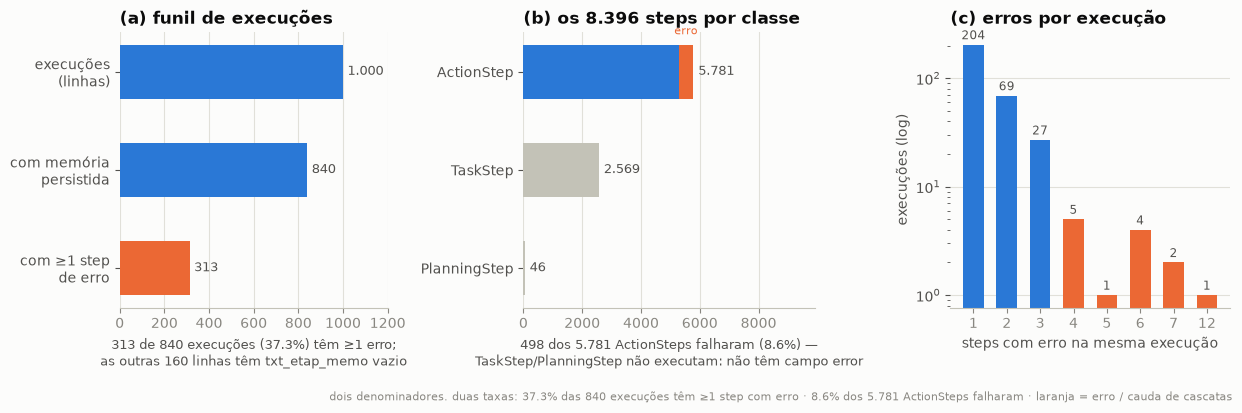

In [19]:
# Overview da granularidade: execução → step → erro (números medidos no cru)
n_exec, n_memo, n_com_erro = len(df), len(execs), int(execs["com_erro"].sum())
n_steps, n_err = len(steps), len(E)

# censo das 3 classes de step dentro do JSON cru (steps só tem ActionStep)
classes, n_sem_memo = Counter(), 0
for v in df["txt_etap_memo"]:
    if pd.isna(v):
        n_sem_memo += 1
        continue
    try:
        memo = json.loads(v)
    except Exception:
        continue
    for role, lst in memo.items():
        if isinstance(lst, list):
            classes.update(s.get("__class__") for s in lst if isinstance(s, dict))
n_act, n_task, n_plan = classes["ActionStep"], classes["TaskStep"], classes["PlanningStep"]

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(12.5, 3.9), gridspec_kw={"width_ratios": [1.15, 1.25, 1.2]})
fig.subplots_adjust(wspace=0.34)

# (a) funil de execuções: 1.000 linhas → 840 com memória → 313 com ≥1 erro
lbl = ["execuções\n(linhas)", "com memória\npersistida", "com ≥1 step\nde erro"]
val = [n_exec, n_memo, n_com_erro]
a1.barh(lbl[::-1], val[::-1], color=[ORANGE, BLUE, BLUE], height=0.55)
for i, v in enumerate(val[::-1]):
    a1.text(v + n_exec * 0.02, i, f"{v:,}".replace(",", "."), va="center", color=INK2, fontsize=9)
a1.set_xlim(0, n_exec * 1.2)
style_ax(a1)
a1.set_title("(a) funil de execuções")
a1.set_xlabel(f"{n_com_erro} de {n_memo} execuções ({n_com_erro/n_memo:.1%}) têm ≥1 erro;\n"
              f"as outras {n_sem_memo} linhas têm txt_etap_memo vazio", fontsize=9)

# (b) os steps do cru por classe — o campo error só existe no ActionStep
nomes, cnts = ["ActionStep", "TaskStep", "PlanningStep"], [n_act, n_task, n_plan]
y, tot = [2, 1, 0], n_act + n_task + n_plan
a2.barh(y[0], n_act - n_err, color=BLUE, height=0.55)
a2.barh(y[0], n_err, left=n_act - n_err, color=ORANGE, height=0.55)
a2.barh(y[1:], cnts[1:], color=BASE, height=0.55)
a2.set_yticks(y, nomes)
for yi, v in zip(y, cnts):
    a2.text(v + tot * 0.02, yi, f"{v:,}".replace(",", "."), va="center", color=INK2, fontsize=9)
a2.annotate("erro", xy=(n_act - n_err / 2, y[0] + 0.38), ha="center", fontsize=8, color=ORANGE)
a2.set_xlim(0, tot * 1.18)
style_ax(a2)
a2.set_title(f"(b) os {tot:,} steps por classe".replace(",", "."))
a2.set_xlabel((f"{n_err} dos {n_act:,} ActionSteps falharam ({n_err/n_act:.1%}) —\n"
               "TaskStep/PlanningStep não executam: não têm campo error").replace(",", "."), fontsize=9)

# (c) erros por execução: a moda é 1; a cauda são as cascatas (recorde: 12)
per = E.groupby("exec_id").size().value_counts().sort_index()
cores = [BLUE if k <= 3 else ORANGE for k in per.index]
a3.bar([str(k) for k in per.index], per.values, color=cores, width=0.62)
for i, v in enumerate(per.values):
    a3.text(i, v * 1.12, str(v), ha="center", color=INK2, fontsize=8.5)
a3.set_yscale("log")
style_ax(a3, xgrid=False)
a3.set_title("(c) erros por execução")
a3.set_xlabel("steps com erro na mesma execução")
a3.set_ylabel("execuções (log)")

fig.text(0.99, -0.04, f"dois denominadores, duas taxas: {n_com_erro/n_memo:.1%} das {n_memo} execuções têm ≥1 step com erro "
         f"· {n_err/n_act:.1%} dos {n_act:,} ActionSteps falharam · laranja = erro / cauda de cascatas".replace(",", "."),
         ha="right", fontsize=8, color=MUTED)
plt.tight_layout(); plt.show()

### 8.1 · A distribuição dos erros por mensagem de erro (sintoma)

As 2 mensagens mais frequentes estão em laranja; o rótulo no canto diz quanto elas somam dos erros e dos tokens.

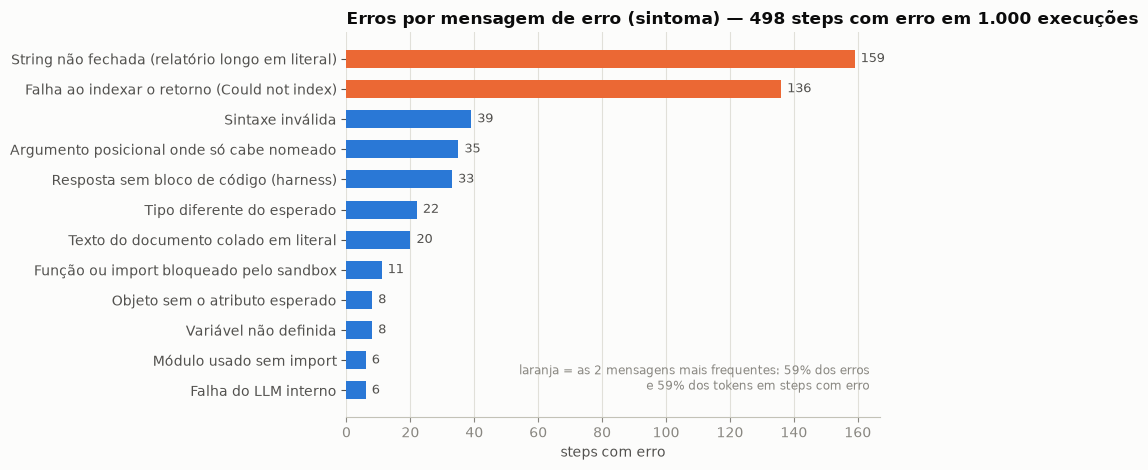

In [20]:
top = E["assinatura"].value_counts().head(12)
cores = [ORANGE if i < 2 else BLUE for i in range(len(top))]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(top.index[::-1], top.values[::-1], color=cores[::-1], height=0.6)
for i, v in enumerate(top.values[::-1]):
    ax.text(v + top.max()*0.012, i, f"{v}", va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title(f"Erros por mensagem de erro (sintoma) — {len(E)} steps com erro em {len(df):,} execuções".replace(",", "."))
ax.set_xlabel("steps com erro")
top2 = E["assinatura"].isin(top.index[:2])
ax.text(0.98, 0.06, f"laranja = as 2 mensagens mais frequentes: {top2.mean():.0%} dos erros\n"
        f"e {E.loc[top2, 'tok_tot'].sum() / E['tok_tot'].sum():.0%} dos tokens em steps com erro",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=MUTED)
plt.tight_layout(); plt.show()

### 8.2 · A mensagem de erro chega ao step seguinte — e o erro se repete?

Cada barra é um subconjunto da anterior. **Como ler:** a queda entre a 1ª e a 2ª barra é o que o harness não
repassou ao contexto; a última barra mede quantos, mesmo com o erro no contexto, erraram de novo na mesma
mensagem. Ela compara pela **mensagem de erro**; comparando pelo **mecanismo**, o número está no rótulo da
última barra (a diferença é explicada na §5).

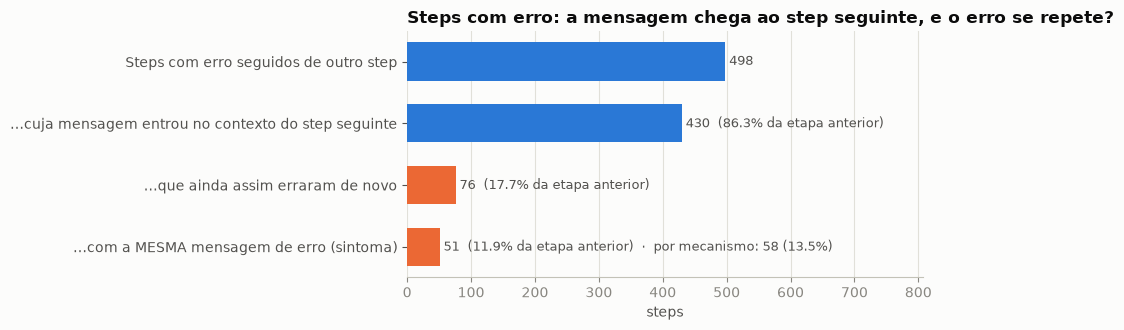

In [21]:
etapas = [
    ("Steps com erro seguidos de outro step", checked, None),
    ("…cuja mensagem entrou no contexto do step seguinte", reached, checked),
    ("…que ainda assim erraram de novo", repeated, reached),
    ("…com a MESMA mensagem de erro (sintoma)", same_sig, reached),
]
labels = [e[0] for e in etapas][::-1]
vals   = [e[1] for e in etapas][::-1]
cores  = [ORANGE, ORANGE, BLUE, BLUE]

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.barh(labels, vals, color=cores, height=0.62)
for i, (lab, v, base) in enumerate(list(etapas)[::-1]):
    txt = f"{v}" if base is None else f"{v}  ({v/base:.1%} da etapa anterior)"
    if lab.startswith("…com a MESMA mensagem"):
        txt += f"  ·  por mecanismo: {same_mec} ({same_mec/base:.1%})"
    ax.text(v + checked*0.012, i, txt, va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Steps com erro: a mensagem chega ao step seguinte, e o erro se repete?")
ax.set_xlabel("steps"); ax.set_xlim(0, checked*1.62)
plt.tight_layout(); plt.show()

### 8.3 · Custo de uma execução com erro × sem erro

O preço do erro em tokens e em passos, e quantas trajetórias terminam num step com erro (no título). As duas
medidas têm grandezas incomparáveis, então são **dois painéis com escalas próprias**, nunca dois eixos no mesmo
gráfico.

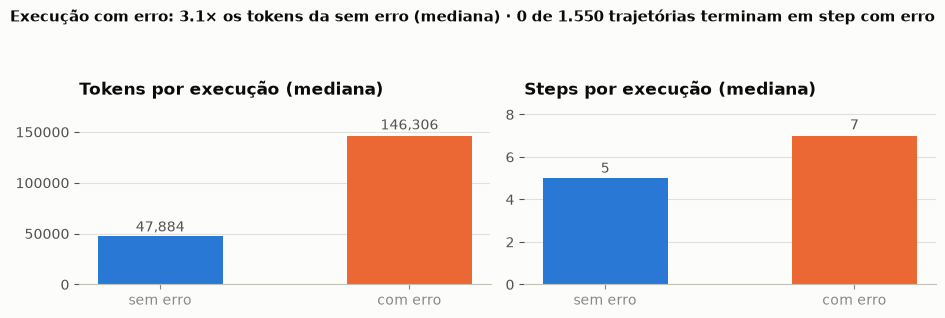

In [22]:
med = execs.groupby("com_erro")[["tok_tot","n_steps"]].median()
sem, com = med.loc[False], med.loc[True]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, campo, titulo, fmt, div in [
    (a1, "tok_tot", "Tokens por execução (mediana)", "{:,.0f}", 1),
    (a2, "n_steps", "Steps por execução (mediana)", "{:.0f}", 1)]:
    v = [med.loc[False, campo]/div, med.loc[True, campo]/div]
    b = ax.bar(["sem erro","com erro"], v, color=[BLUE, ORANGE], width=0.5)
    for rect, val in zip(b, v):
        ax.text(rect.get_x()+rect.get_width()/2, val*1.02, fmt.format(val),
                ha="center", va="bottom", color=INK2, fontsize=10)
    ax.set_title(titulo); style_ax(ax, xgrid=False); ax.set_ylim(0, max(v)*1.22)

# título dinâmico: recomputado de `steps`/`execs`, não hardcoded — sobrevive a reuso do
# notebook noutra extração/trace, onde esses números mudam.
custo_x = com["tok_tot"] / sem["tok_tot"]
n_traj = steps.groupby(["exec_id", "role"]).ngroups
termina_em_erro = int(((steps["idx"] == steps["n_steps_role"] - 1) & steps["err_type"].notna()).sum())
fig.suptitle(f"Execução com erro: {custo_x:.1f}× os tokens da sem erro (mediana) · "
             f"{termina_em_erro} de {n_traj:,} trajetórias terminam em step com erro".replace(",", "."),
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.90]); plt.show()

### 8.4 · Erros por mecanismo e mês

Cada célula é o número de erros daquele **mecanismo** (unidade, célula "Do sintoma ao mecanismo") no mês em que a
execução rodou. São os 8 mecanismos com mais erros. **Como ler:** células preenchidas espalhadas na horizontal =
o mesmo mecanismo volta em meses diferentes (recorrência entre execuções); concentração numa coluna só = surto
pontual (ex.: um incidente de harness).

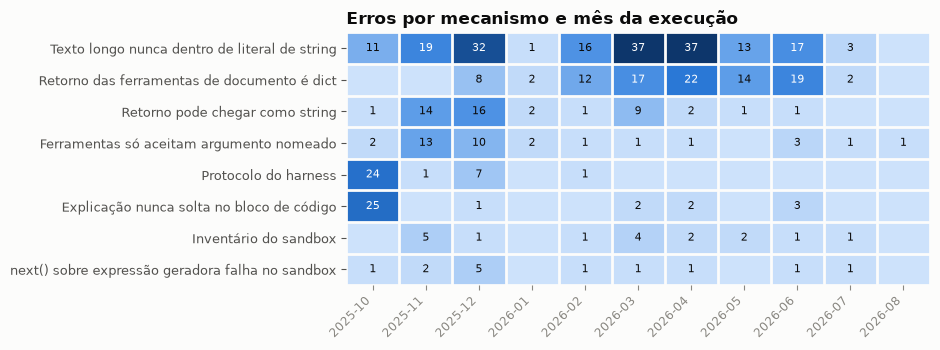

In [23]:
from matplotlib.colors import LinearSegmentedColormap
RAMP = LinearSegmentedColormap.from_list("blue_seq",
        ["#cde2fb","#9ec5f4","#5598e7","#2a78d6","#1c5cab","#0d366b"])

nome_mec = EU["unidade"].map(lambda u: UNI[u][0])
piv = (EU.assign(mecanismo=nome_mec).pivot_table(index="mecanismo", columns="mes", values="exec_id",
                                                 aggfunc="count").fillna(0))
piv = piv.loc[nome_mec.value_counts().head(8).index]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
im = ax.imshow(piv.values, cmap=RAMP, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([s[:52] for s in piv.index], fontsize=9)
vmax = piv.values.max()
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=8,
                    color="#ffffff" if v > vmax*0.45 else INK)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(np.arange(-.5, len(piv.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(piv.index), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2); ax.tick_params(which="minor", length=0)
ax.set_title("Erros por mecanismo e mês da execução")
plt.tight_layout(); plt.show()

### 8.5 · Tokens desperdiçados por mecanismo aprendível

Tokens gastos em steps que terminaram em erro — output descartado —, **por mecanismo**: memória se escreve por lição, não por mensagem. Só entram mecanismos que o agente pode aprender (*factual · ambiente* ou *experiencial · estratégia*); falhas de harness/infra e erros pontuais ficam de fora aqui e aparecem na triagem completa do §9.3, que também aplica o critério de recorrência.

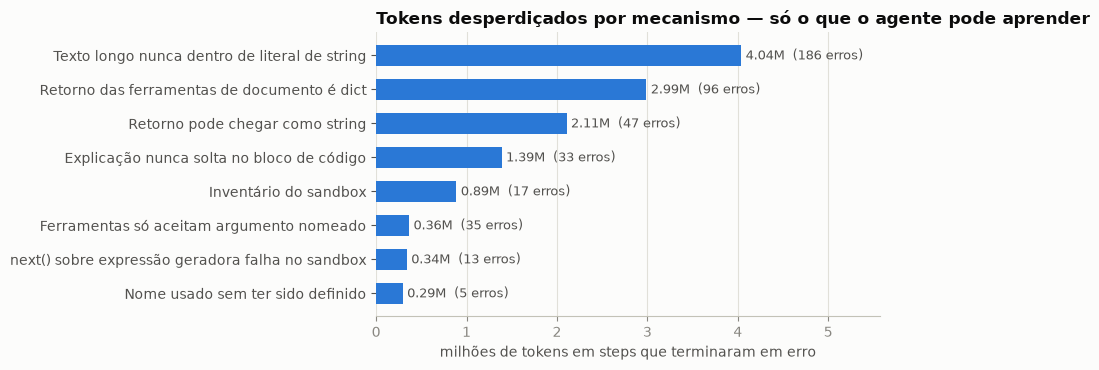

In [24]:
aprendiveis = {UNI[u][0] for u in UNI if UNI[u][1] in (FACT, ESTR)}
pay = payoff_mec[payoff_mec.index.isin(aprendiveis)].head(8).sort_values("tokens")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh([s[:52] for s in pay.index], pay["tokens"]/1e6, color=BLUE, height=0.6)
for i, (v, e) in enumerate(zip(pay["tokens"]/1e6, pay["erros"])):
    ax.text(v + pay["tokens"].max()/1e6*0.012, i, f"{v:.2f}M  ({e} erros)",
            va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Tokens desperdiçados por mecanismo — só o que o agente pode aprender")
ax.set_xlabel("milhões de tokens em steps que terminaram em erro")
ax.set_xlim(0, (pay["tokens"].max()/1e6)*1.38)
plt.tight_layout(); plt.show()

### 8.6 · Onde o erro acontece — e quem erra

Dois recortes de diagnóstico. À esquerda, a posição do step na trajetória, **restrita aos índices com amostra
suficiente** e com o `n` impresso em cada barra (sem isso a leitura seria enganosa). À direita, a taxa por papel.

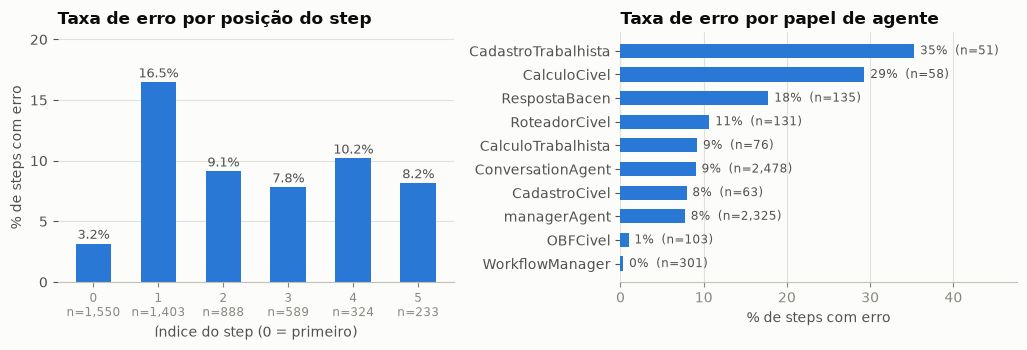

In [25]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.6))

gg = steps.groupby("idx").agg(n=("err_type","size"), e=("err_type", lambda s: s.notna().sum()))
gg = gg[gg["n"] >= 200]; gg["taxa"] = gg["e"]/gg["n"]*100
a1.bar(range(len(gg)), gg["taxa"], color=BLUE, width=0.55)
for x, taxa in enumerate(gg["taxa"]):
    a1.text(x, taxa + 0.4, f"{taxa:.1f}%", ha="center", color=INK2, fontsize=9)
a1.set_xticks(range(len(gg)))
a1.set_xticklabels([f"{i}\nn={n:,}" for i, n in zip(gg.index, gg["n"])], fontsize=8.5)
a1.set_title("Taxa de erro por posição do step")
a1.set_xlabel("índice do step (0 = primeiro)"); a1.set_ylabel("% de steps com erro")
a1.set_ylim(0, gg["taxa"].max()*1.25); style_ax(a1, xgrid=False)

pr = (steps.groupby("role").agg(n=("err_type","size"), e=("err_type", lambda s: s.notna().sum())))
pr = pr[pr["n"] >= 30]; pr["taxa"] = pr["e"]/pr["n"]*100
pr = pr.sort_values("taxa")
a2.barh(pr.index, pr["taxa"], color=BLUE, height=0.6)
for i, (taxa, n) in enumerate(zip(pr["taxa"], pr["n"])):
    a2.text(taxa + pr["taxa"].max()*0.02, i, f"{taxa:.0f}%  (n={n:,})", va="center", color=INK2, fontsize=8.5)
a2.set_title("Taxa de erro por papel de agente"); a2.set_xlabel("% de steps com erro")
a2.set_xlim(0, pr["taxa"].max()*1.35); style_ax(a2)
plt.tight_layout(); plt.show()

### 8.7 · Concentração de custo — curva de Lorenz

Cada ponto no eixo x é "as N% execuções mais caras"; o eixo y é a fatia do gasto total que elas carregam. A
linha tracejada é a distribuição perfeitamente igualitária (se todas as execuções custassem o mesmo). Quanto
mais a curva azul se afasta da diagonal, mais concentrado é o custo.

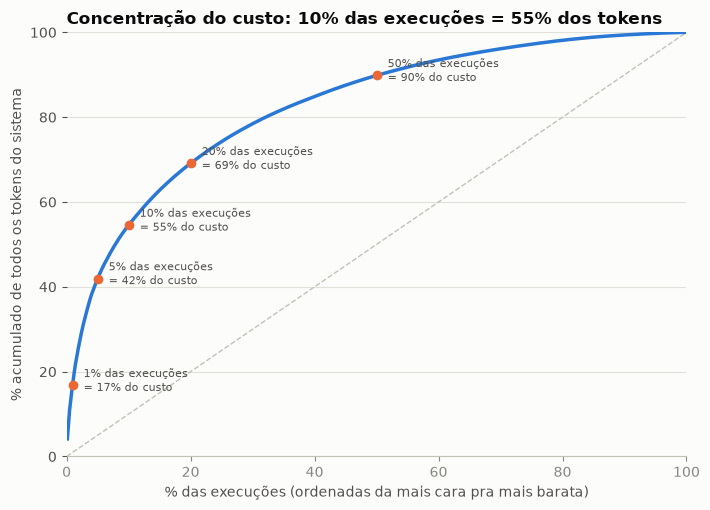

In [26]:
toks_desc = execs["tok_tot"].sort_values(ascending=False).values
cum = np.cumsum(toks_desc) / toks_desc.sum() * 100
x = np.arange(1, len(toks_desc) + 1) / len(toks_desc) * 100

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot([0, 100], [0, 100], color=BASE, linewidth=1, linestyle="--")
ax.plot(x, cum, color=BLUE, linewidth=2.5)
for pct in (1, 5, 10, 20, 50):
    idx = max(1, round(len(toks_desc) * pct / 100)) - 1
    ax.scatter([x[idx]], [cum[idx]], color=ORANGE, zorder=5, s=36)
    ax.annotate(f"{pct}% das execuções\n= {cum[idx]:.0f}% do custo", (x[idx], cum[idx]),
                textcoords="offset points", xytext=(8, -4), fontsize=8, color=INK2)
ax.set_xlabel("% das execuções (ordenadas da mais cara pra mais barata)")
ax.set_ylabel("% acumulado de todos os tokens do sistema")
k10 = max(1, round(len(toks_desc) * 10 / 100)) - 1
ax.set_title(f"Concentração do custo: 10% das execuções = {cum[k10]:.0f}% dos tokens")
style_ax(ax, xgrid=False)
ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

### 8.8 · Unidade de erro por papel

Cada barra soma 100% dos erros daquele papel, por **unidade** (N4 — o nível mais específico da taxonomia, não a
família genérica do §2). `n=` no rótulo é o volume de erros do papel — a barra normalizada a 100% não esconde que
um papel pode ter poucos erros. **Cores** (fixas por nome em `paleta.py`, iguais em qualquer run): as 5 unidades
de `CAT_U` têm cor própria; o cinza claro junta as outras unidades **candidatas** a memória pela triagem (§9);
o roxo é o **resíduo a revisar** — erros que nenhuma regra de causa reconheceu (trabalho de taxonomia, não memória);
o cinza escuro é **o que não vira memória** — harness/infra e as reprovadas na triagem. Unidade ausente numa base
simplesmente não aparece.

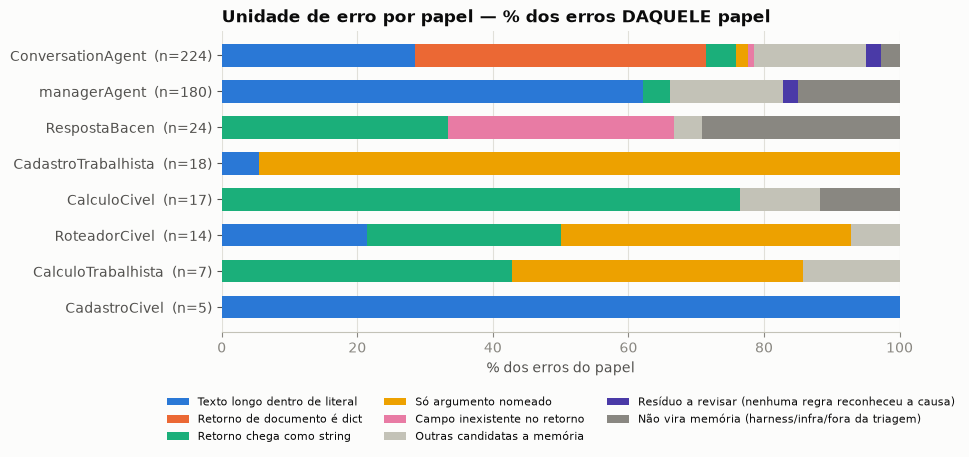

In [27]:
# CAT_U e COR_UNIDADE vêm de paleta.py: a cor segue o NOME da fatia, não a posição — unidade
# ausente num recorte some da barra sem deslocar a cor das outras
LABEL_CURTO = {
    "U_texto_literal": "Texto longo dentro de literal",
    "U_contrato_dict": "Retorno de documento é dict",
    "U_tipo_retorno": "Retorno chega como string",
    "U_arg_nomeado": "Só argumento nomeado",
    "U_campo_inexistente": "Campo inexistente no retorno",
    "Outras candidatas": "Outras candidatas a memória",
    "Resíduo — revisar": "Resíduo a revisar (nenhuma regra reconheceu a causa)",
    "Não vira memória": "Não vira memória (harness/infra/fora da triagem)",
}

role_vol2 = EU["role"].value_counts()
roles_ord = role_vol2[role_vol2 >= 5].sort_values().index
tab_rf = pd.crosstab(EU["role"], EU["unidade"]).reindex(roles_ord).fillna(0)
den = tab_rf.sum(axis=1)
norm8 = tab_rf[[c for c in CAT_U if c in tab_rf.columns]].div(den, axis=0) * 100

# o resto da barra desdobrado pela DECISÃO DA TRIAGEM (§9.3): candidatas menores × o que não vira
# memória (não-memória + reprovadas na triagem) — cor segue o destino, não o tamanho
cand88 = set(triagem(EU).loc[lambda t: t["decisão"] == "candidato", "unidade"])
unid_menores = [u for u in tab_rf.columns if u not in CAT_U and u in cand88]
residuo = [u for u in tab_rf.columns if u.startswith("X_")]  # resíduo não é não-memória: falta a regra de causa
nao_memoria = [u for u in tab_rf.columns if u not in CAT_U and u not in cand88 and u not in residuo]
norm8["Outras candidatas"] = tab_rf[unid_menores].sum(axis=1).div(den, axis=0) * 100
norm8["Resíduo — revisar"] = tab_rf[residuo].sum(axis=1).div(den, axis=0) * 100
norm8["Não vira memória"] = tab_rf[nao_memoria].sum(axis=1).div(den, axis=0) * 100
norm8.index = [f"{r}  (n={int(den[r])})" for r in norm8.index]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
left = np.zeros(len(norm8))
for col in norm8.columns:  # cinza claro = candidata também · cinza escuro = não vira memória
    ax.barh(norm8.index, norm8[col], left=left, color=COR_UNIDADE[col], height=0.62,
            label=LABEL_CURTO.get(col, col))
    left += norm8[col].values
ax.set_xlim(0, 100)
ax.set_title("Unidade de erro por papel — % dos erros DAQUELE papel")
ax.set_xlabel("% dos erros do papel")
style_ax(ax, xgrid=False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### 8.9 · Tokens por chamada de ferramenta, por papel

Eficiência por unidade de trabalho real — eixo independente da taxa de erro. Em laranja, os papéis acima de 2× a
**mediana por execução** (a linha pontilhada) — não a razão agregada, que é outra estatística (ver §3.3).

> Papéis com nome malformado (`null`, nome truncado) são artefato de serialização do campo de papel na fonte, não
> papéis "de verdade" — aparecem porque o dado é real, mas não valem decisão de priorização sem investigar a chave.

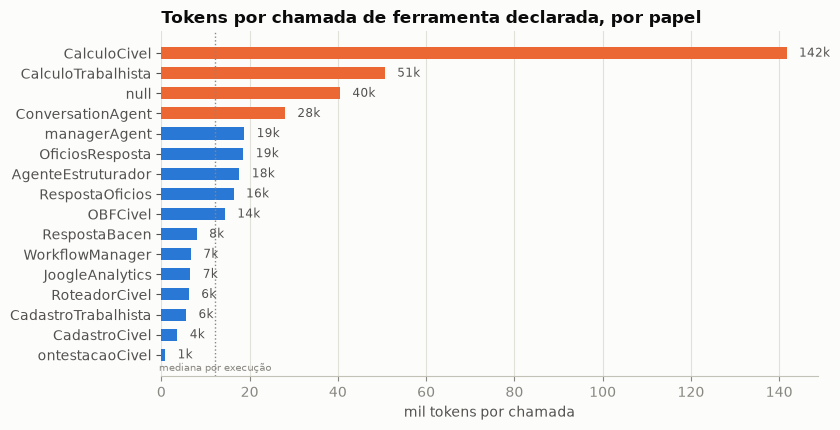

In [28]:
efp = EF.sort_values("tok_por_chamada")
# CORRIGIDO (auditoria independente, S1): a referência é a MEDIANA das razões por execução
# (12.192), não a razão agregada soma/soma (21.420). Rotular a agregada como "mediana" era o
# mesmo erro que §3.3 já tinha corrigido na prosa — o gráfico tinha ficado de fora.
cores9 = [ORANGE if v > mediana_por_exec * 2 else BLUE for v in efp["tok_por_chamada"]]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(efp["role"], efp["tok_por_chamada"] / 1000, color=cores9, height=0.6)
for i, v in enumerate(efp["tok_por_chamada"] / 1000):
    ax.text(v + efp["tok_por_chamada"].max() / 1000 * 0.02, i, f"{v:.0f}k", va="center", color=INK2, fontsize=8.5)
ax.axvline(mediana_por_exec / 1000, color=MUTED, linewidth=1, linestyle=":")
ax.text(mediana_por_exec / 1000, -0.8, "mediana por execução", color=MUTED, fontsize=7.5, ha="center")
ax.set_title("Tokens por chamada de ferramenta declarada, por papel")
ax.set_xlabel("mil tokens por chamada")
style_ax(ax)
plt.tight_layout(); plt.show()

### 8.10 · A prioridade muda conforme o critério

O mesmo conjunto de papéis, ranqueado duas vezes: por percentual do próprio orçamento desperdiçado, e por
volume absoluto de tokens desperdiçados. As linhas cruzando mostram a reordenação; em laranja, o 1º de cada ranking.

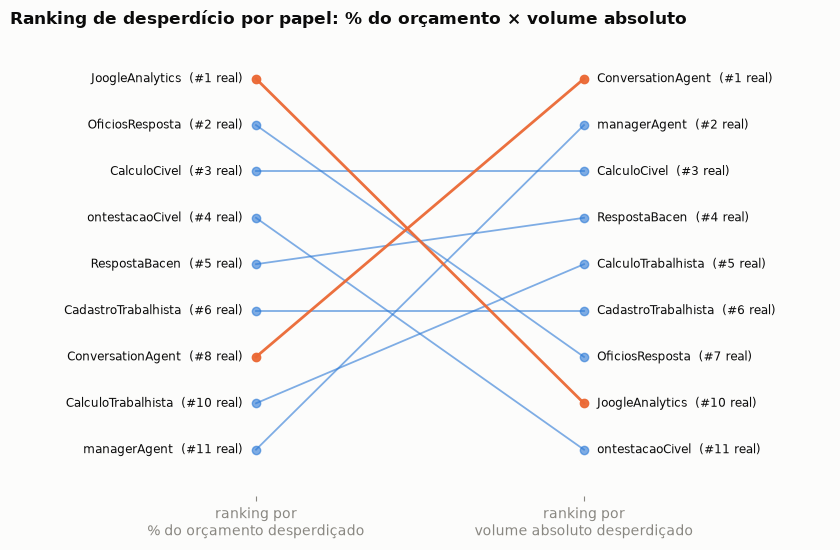

In [29]:
rank_pct = {r: i for i, r in enumerate(OR.sort_values("%_desperdicado", ascending=False).index)}
rank_abs = {r: i for i, r in enumerate(OR.sort_values("tok_erro", ascending=False).index)}
roles_show = set(list(rank_pct)[:6]) | set(list(rank_abs)[:6])

# posições verticais COMPACTAS (0..n-1) para os papéis exibidos — usar o rank bruto (que pode ter
# buracos, já que só mostramos um subconjunto) causava rótulos sobrepostos no canto de amostra maior.
left_order = sorted(roles_show, key=lambda r: rank_pct[r])
right_order = sorted(roles_show, key=lambda r: rank_abs[r])
y_left = {r: i for i, r in enumerate(left_order)}
y_right = {r: i for i, r in enumerate(right_order)}

fig, ax = plt.subplots(figsize=(8.5, 5.6))
for r in sorted(roles_show):  # ordem fixa: iterar o set mudava a ordem de desenho a cada execução
    y1, y2 = y_left[r], y_right[r]
    destaque = r in (left_order[0], right_order[0])  # o 1º de cada ranking
    cor = ORANGE if destaque else BLUE
    ax.plot([0, 1], [y1, y2], color=cor, linewidth=2 if destaque else 1.3,
            alpha=0.95 if destaque else 0.6, marker="o", markersize=6, zorder=3 if destaque else 2)
    ax.text(-0.04, y1, f"{r}  (#{rank_pct[r]+1} real)", ha="right", va="center", fontsize=8.5, color=INK)
    ax.text(1.04, y2, f"{r}  (#{rank_abs[r]+1} real)", ha="left", va="center", fontsize=8.5, color=INK)
ax.set_xlim(-0.75, 1.75)
ax.set_ylim(len(roles_show), -1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["ranking por\n% do orçamento desperdiçado", "ranking por\nvolume absoluto desperdiçado"])
for s in ax.spines.values(): s.set_visible(False)
ax.set_yticks([])
ax.set_title("Ranking de desperdício por papel: % do orçamento × volume absoluto")
plt.tight_layout(); plt.show()

### 8.11 · Evolução mensal do custo por execução

Barras em cinza são meses com amostra pequena demais pra confiar (`n < 20`).

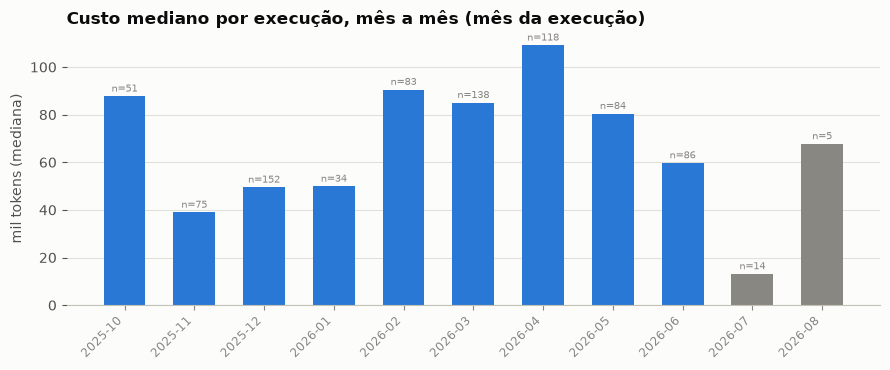

In [30]:
pm = execs.groupby("mes")["tok_tot"].median()
n_pm = execs.groupby("mes").size()
cores11 = [MUTED if n_pm[m] < 20 else BLUE for m in pm.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(len(pm)), pm.values / 1000, color=cores11, width=0.6)
for i, m in enumerate(pm.index):
    ax.text(i, pm[m] / 1000 + 2, f"n={n_pm[m]}", ha="center", color=MUTED, fontsize=7.5)
ax.set_xticks(range(len(pm))); ax.set_xticklabels(pm.index, rotation=45, ha="right", fontsize=8.5)
ax.set_title("Custo mediano por execução, mês a mês (mês da execução)")
ax.set_ylabel("mil tokens (mediana)")
style_ax(ax, xgrid=False)
ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### 8.12 · Sucesso verificado por conteúdo

Continuação do funil da seção 8.2, agora checando o CONTEÚDO da resposta, não só se `final_answer` foi
chamado.

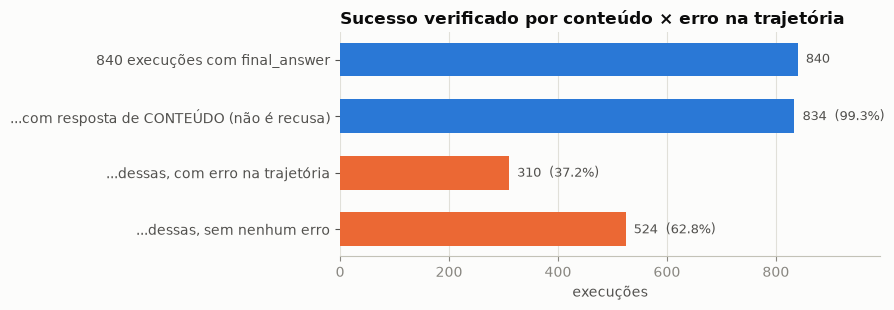

In [31]:
labels12 = [f"{len(S)} execuções com final_answer", "...com resposta de CONTEÚDO (não é recusa)",
            "...dessas, com erro na trajetória", "...dessas, sem nenhum erro"]
vals12 = [len(S), int(S["sucesso"].sum()), int((S["sucesso"] & S["com_erro"]).sum()),
          int((S["sucesso"] & ~S["com_erro"]).sum())]
cores12 = [BLUE, BLUE, ORANGE, ORANGE]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(labels12[::-1], vals12[::-1], color=cores12[::-1], height=0.6)
# denominador de cada percentual: os 2 primeiros são % de 840 (total); os 2 últimos são % de 834
# (as com resposta de conteúdo) — usar 840 nos 4 daria número errado (36,9% em vez de 37,2%).
bases12 = [None, len(S), int(S["sucesso"].sum()), int(S["sucesso"].sum())]
for i, (v, base) in enumerate(zip(vals12[::-1], bases12[::-1])):
    pct = f"  ({v/base:.1%})" if base else ""
    ax.text(v + 15, i, f"{v}{pct}", va="center", color=INK2, fontsize=9)
style_ax(ax)
ax.set_title("Sucesso verificado por conteúdo × erro na trajetória")
ax.set_xlabel("execuções"); ax.set_xlim(0, len(S) * 1.18)
plt.tight_layout(); plt.show()

## 9 · Candidatos a unidades de memória

Do **sintoma** (a `assinatura` regex da §2) à **unidade de memória** (um conteúdo escrevível numa frase). Três passos, todos determinísticos:

1. **Submecanismo por erro** (célula "Do sintoma ao mecanismo", §2) — regra explícita sobre a mensagem de exceção e a linha que o parser rejeitou (`submecanismo()`). Uma assinatura pode se dividir em várias unidades, e várias assinaturas podem cair na mesma unidade.
2. **Ocorrência, não erro** (célula "Do sintoma ao mecanismo", §2) — erros consecutivos do mesmo papel na mesma execução formam uma *cascata*; a mesma unidade repetida dentro dela conta **uma** vez. O princípio "causa-raiz, não sintoma de superfície" é do AgentDebug (arXiv 2509.25370, p. 2 e p. 8); esta operacionalização por cascata é nossa.
3. **Triagem** (9.2) — `não-memória` (harness/infra) fica fora do agente; os dois baldes de resíduo — **causa não identificada** e **sintoma não reconhecido** (nenhuma regra reconheceu o erro; `../docs/01-racionais.md` §7) — nunca são candidatos: vão para **revisar**, com **prioridade** se algum **padrão de erro** (classe da exceção + frase mascarada) passar no teste de recorrência, e **baixa prioridade** se nenhum passar — a tabela "resíduo por padrão" é a lista de trabalho para escrever regra nova; menos de **3 execuções ou 2 meses** de ocorrências fica fora (sem recorrência entre execuções, não há o que uma memória *cross-trial* resolva). O resto é candidato. Sensibilidade com ≥5 execuções e ≥3 meses impressa junto.

O **tipo** vem da função do conteúdo em Hu et al. 2025, *Memory in the Age of AI Agents* (arXiv 2512.13564, §4): **factual · ambiente** responde "o que é verdade sobre ferramentas, sandbox e documentos?" (§4.1.2, p. 36); **experiencial · estratégia** responde "que regra de decisão evita repetir a falha?" (§4.2.2, *Insights*, p. 40). Harness/infra não é memória do agente e fica fora da taxonomia. Passo a passo, critérios e ressalvas em [`../docs/01-racionais.md`](../docs/01-racionais.md) §7.

In [32]:
# 9.2 · Triagem, tabelas e exportação
T = triagem(EU)
TS = triagem(EU, 5, 3)
ASS = pd.crosstab(EU["assinatura"], EU["unidade"])
DOM = pd.DataFrame({"erros": ASS.sum(axis=1), "unidades": (ASS > 0).sum(axis=1),
                    "unidade dominante": ASS.idxmax(axis=1).map(lambda u: UNI[u][0]),
                    "% na dominante": (ASS.max(axis=1) / ASS.sum(axis=1) * 100).round().astype(int),
                    "% seguidor": EU.groupby("assinatura")["seguidor"].mean().mul(100).round().astype(int)}
                   ).sort_values("erros", ascending=False)

cand = T[T["decisão"] == "candidato"]
limitrofes = sorted(set(cand["nome"]) - set(TS.loc[TS["decisão"] == "candidato", "nome"]))
print(f"{len(EU)} erros → {EU['ocorrencia'].nunique()} ocorrências (cascata × unidade) → {len(T)} unidades: "
      f"{len(cand)} candidatas, {(T['decisão'] == 'não-memória').sum()} não-memória, "
      f"{T['decisão'].str.startswith('revisar').sum()} a revisar, {T['decisão'].str.startswith('fora').sum()} fora")
print(f"candidatas: {cand['erros'].sum()} dos {len(EU)} erros ({cand['erros'].sum() / len(EU):.0%}) · "
      f"{cand['tokens'].sum() / EU['tok_tot'].sum():.0%} dos tokens em steps com erro")
print(f"sensibilidade (≥5 execuções e ≥3 meses) — deixam de ser candidatas: {limitrofes or 'nenhuma'}")
display(T.drop(columns=["unidade", "assinaturas de origem", "conteúdo proposto"]))
print("Cada assinatura regex da §2 → em quantas unidades ela se divide:")
display(DOM)
RP = residuo_por_padrao(EU)
print(f"resíduo por padrão de erro — {len(RP)} padrões, {int(RP['passa na recorrência'].sum())} passam na recorrência:")
display(RP)

import os
os.makedirs("resultados", exist_ok=True)
T.to_csv("resultados/candidatos_memoria.csv", index=False)
DOM.to_csv("resultados/triagem_assinaturas.csv")
RP.to_csv("resultados/residuo_padroes.csv", index=False)
payoff.to_csv("resultados/payoff_assinaturas.csv")
rec.to_csv("resultados/reincidencia.csv")
E.assign(err_msg=E["err_msg"].str.slice(0,400)).to_csv("resultados/erros_classificados.csv", index=False)
execs.to_csv("resultados/execucoes.csv", index=False)
(EU.assign(unidade_nome=EU["unidade"].map(lambda u: UNI[u][0]))
   [["exec_id", "role", "mes", "idx", "step", "assinatura", "submecanismo", "unidade", "unidade_nome",
     "seguidor", "cascata", "tok_tot"]]
   .to_csv("resultados/erros_mecanismo.csv", index=False))
print("Exportado para resultados/")


498 erros → 437 ocorrências (cascata × unidade) → 15 unidades: 10 candidatas, 2 não-memória, 2 a revisar, 1 fora
candidatas: 447 dos 498 erros (90%) · 92% dos tokens em steps com erro
sensibilidade (≥5 execuções e ≥3 meses) — deixam de ser candidatas: ['Após step com erro, o que ele definiria não existe']


,nome,tipo,decisão,ocorrências,erros,reincidências na cascata,execuções,meses,papéis,tokens,% ocorr. após outro erro
10,Texto longo nunca dentro de literal de string,experiencial · estratégia,candidato,173,186,13,149,10,6,4038107,1
4,Retorno das ferramentas de documento é dict,factual · ambiente,candidato,87,96,9,87,8,1,2989426,1
12,Retorno pode chegar como string,experiencial · estratégia,candidato,42,47,5,36,9,7,2106255,5
11,Explicação nunca solta no bloco de código,experiencial · estratégia,candidato,12,33,21,12,5,3,1388050,67
9,Inventário do sandbox,factual · ambiente,candidato,17,17,0,17,8,6,887853,35
2,Ferramentas só aceitam argumento nomeado,factual · ambiente,candidato,24,35,11,22,10,7,364543,4
6,next() sobre expressão geradora falha no sandbox,factual · ambiente,candidato,11,13,2,11,8,2,339280,9
7,Nome usado sem ter sido definido,experiencial · estratégia,candidato,5,5,0,5,4,2,294106,0
5,"Após step com erro, o que ele definiria não ex...",experiencial · estratégia,candidato,5,5,0,4,3,2,213853,100
3,Campo inexistente no retorno estruturado,factual · ambiente,candidato,10,10,0,10,6,2,192456,20


Cada assinatura regex da §2 → em quantas unidades ela se divide:


,erros,unidades,unidade dominante,% na dominante,% seguidor
assinatura,,,,,
String não fechada (relatório longo em literal),159,1,Texto longo nunca dentro de literal de string,100,9
Falha ao indexar o retorno (Could not index),136,3,Retorno das ferramentas de documento é dict,65,8
Sintaxe inválida,39,4,Explicação nunca solta no bloco de código,72,67
Argumento posicional onde só cabe nomeado,35,1,Ferramentas só aceitam argumento nomeado,100,34
Resposta sem bloco de código (harness),33,1,Protocolo do harness,100,0
Tipo diferente do esperado,22,3,next() sobre expressão geradora falha no sandbox,59,14
Texto do documento colado em literal,20,2,Texto longo nunca dentro de literal de string,95,0
Função ou import bloqueado pelo sandbox,11,2,Inventário do sandbox,82,45
Objeto sem o atributo esperado,8,2,Retorno das ferramentas de documento é dict,88,75


resíduo por padrão de erro — 7 padrões, 1 passam na recorrência:


,unidade,submecanismo,padrao,ocorrências,execuções,meses,papéis,erros,passa na recorrência
0,X_causa_nao_identificada,codigo_mal_escrito,SyntaxError: closing parenthesis <q> does not ...,3,3,2,2,3,True
1,X_causa_nao_identificada,causa_sem_regra,TypeError: <q> not supported between instances...,1,1,1,1,1,False
2,X_causa_nao_identificada,causa_sem_regra,TypeError: FinalAnswerTool.forward() got an un...,1,1,1,1,1,False
3,X_causa_nao_identificada,causa_sem_regra,TypeError: unsupported operand type(s) for |: ...,1,1,1,1,1,False
4,X_causa_nao_identificada,causa_sem_regra,ValueError: dictionary update sequence element...,1,1,1,1,1,False
5,X_causa_nao_identificada,codigo_mal_escrito,IndentationError: expected an indented block a...,1,1,1,1,1,False
6,X_sintoma_nao_reconhecido,sintoma_nao_reconhecido,InterpreterError: NoneType is not supported.,1,1,1,1,1,False


Exportado para resultados/


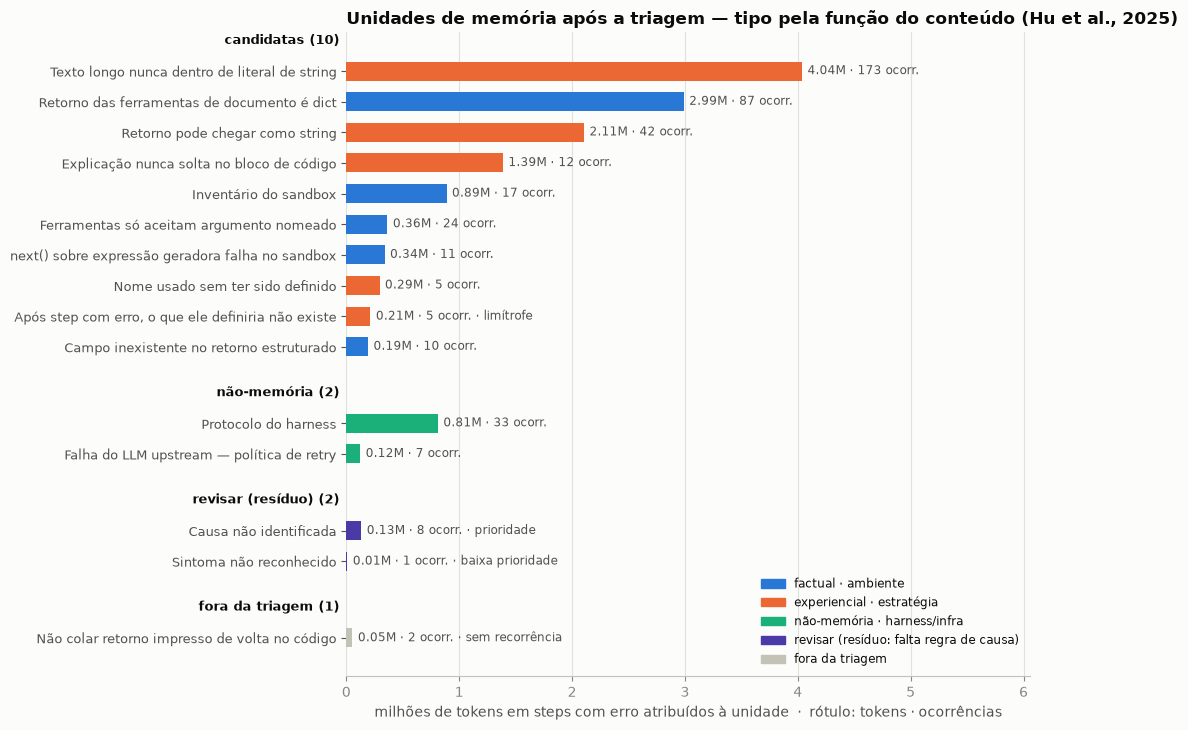

In [33]:
# 9.3 · Gráfico — uma barra por unidade, agrupada pela decisão da triagem; cor = tipo (Hu et al. 2025, §4).
# Slots 1–3 da paleta categórica em ordem fixa (validate_palette.js "#2a78d6,#eb6834,#1baf7a" → PASS; o
# aviso de contraste do verde é coberto pelo rótulo direto em cada barra). "Fora" em cinza neutro, não é série.
from matplotlib.patches import Patch
TIPO_CORES = {FACT: BLUE, ESTR: ORANGE, NAO: "#1baf7a"}
GRUPO = {"candidato": "candidatas", "não-memória": "não-memória",
         REVISAR_PRIORIDADE: "revisar (resíduo)", REVISAR_BAIXA: "revisar (resíduo)",
         "fora: sem recorrência": "fora da triagem"}
xmax = T["tokens"].max() / 1e6

fig, ax = plt.subplots(figsize=(10.5, 7.4))
pos, yticks, ylabels = 0.0, [], []
for grupo in ["candidatas", "não-memória", "revisar (resíduo)", "fora da triagem"]:
    sub = T[T["decisão"].map(GRUPO) == grupo].sort_values("tokens", ascending=False)
    ax.text(-0.01, pos, f"{grupo} ({len(sub)})", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9, fontweight="bold", color=INK)
    pos += 1
    for r in sub.to_dict("records"):
        cor = {"fora da triagem": BASE, "revisar (resíduo)": REVISAR}.get(grupo) or TIPO_CORES[r["tipo"]]
        ax.barh(pos, r["tokens"] / 1e6, color=cor, height=0.62)
        if r["nome"] in limitrofes:
            nota = " · limítrofe"
        elif grupo in ("fora da triagem", "revisar (resíduo)"):
            nota = " · " + r["decisão"].replace("fora: ", "").replace("revisar — ", "")
        else:
            nota = ""
        ax.text(r["tokens"] / 1e6 + xmax * 0.012, pos, f"{r['tokens'] / 1e6:.2f}M · {r['ocorrências']} ocorr.{nota}",
                va="center", color=INK2, fontsize=8.5)
        yticks.append(pos); ylabels.append(r["nome"])
        pos += 1
    pos += 0.5

ax.set_yticks(yticks, ylabels, fontsize=9)
ax.invert_yaxis()
style_ax(ax)
ax.set_xlim(0, xmax * 1.5)
ax.set_title("Unidades de memória após a triagem — tipo pela função do conteúdo (Hu et al., 2025)")
ax.set_xlabel("milhões de tokens em steps com erro atribuídos à unidade  ·  rótulo: tokens · ocorrências")
ax.legend(handles=[Patch(color=BLUE, label=FACT), Patch(color=ORANGE, label=ESTR),
                   Patch(color="#1baf7a", label=NAO), Patch(color=REVISAR, label="revisar (resíduo: falta regra de causa)"),
                   Patch(color=BASE, label="fora da triagem")],
          loc="lower right", fontsize=8.5, frameon=False)
plt.tight_layout(); plt.show()

## 10 · Leitura dos resultados

Síntese narrativa em [`../docs/02-relatorio-achados.md`](../docs/02-relatorio-achados.md); fichamentos dos papers em
[`../literature/`](../literature/).
A mineração das unidades nº2/nº10 (o que era a §11 deste notebook) virou notebook próprio em
18/09/2026: [`mineracao_unidades_n2_n10.ipynb`](mineracao_unidades_n2_n10.ipynb) — mesma fonte, numeração
§11.x preservada para manter a correspondência com `resultados/evidencia/11.*`.
